In [ ]:
from scipy.stats import poisson
import numpy as np
import pandas as pd
from sklearn.metrics import log_loss
import plotly.express as px
import plotly.graph_objects as go
from scipy.optimize import differential_evolution
from tqdm import tqdm
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from IPython.display import display
from typing import Sequence, cast

In [2]:
warnings.filterwarnings('ignore')

In [3]:
# df_22_23 = pd.read_csv('LaLiga_22_23.csv')
# df_23_24 = pd.read_csv('LaLiga_23_24.csv')
# df_24_25 = pd.read_csv('LaLiga_24_25.csv')


# df_22_23 = pd.read_csv('Segunda_inglesa_22_23.csv')
df_23_24 = pd.read_csv('Segunda_inglesa_23_24.csv')
df_24_25 = pd.read_csv('Segunda_inglesa_24_25.csv')

df = pd.concat([df_23_24, df_24_25], ignore_index=True)

# Usamos dayfirst=True para asegurar el formato europeo -> Primer número = día
temp_date = pd.to_datetime(df['Date'], dayfirst=True)
df['Date'] = pd.to_datetime(temp_date.dt.strftime('%Y-%m-%d') + ' ' + df['Time'].astype(str))

# Ordenamos por la nueva columna Date (que ya tiene fecha y hora)
df = df.sort_values('Date').reset_index(drop=True)

# Calcular el número de partido de la temporada para cada equipo
team_game_count = {}
matchdays = []

for idx, row in df.iterrows():
    h, a = row['HomeTeam'], row['AwayTeam']
    # Contamos cuántos partidos ha jugado cada uno hasta ahora
    count_h = team_game_count.get(h, 0) + 1
    count_a = team_game_count.get(a, 0) + 1

    # La jornada real del partido es el máximo de ambos (por si hay partidos aplazados)
    jornada = max(count_h, count_a)
    matchdays.append(jornada)

    # Actualizar contador para el siguiente partido
    team_game_count[h] = count_h
    team_game_count[a] = count_a

df['Jornada'] = matchdays

# Limpieza de columnas no comunes
df.dropna(inplace=True, axis=1)

df

,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,...,AHCh,B365CAHH,B365CAHA,PCAHH,PCAHA,MaxCAHH,MaxCAHA,AvgCAHH,AvgCAHA,Jornada
0,E1,2023-08-04 20:00:00,20:00,Sheffield Weds,Southampton,1,2,A,0,1,...,0.25,1.91,1.99,1.93,2.00,1.97,2.00,1.88,1.95,1
1,E1,2023-08-05 15:00:00,15:00,Swansea,Birmingham,1,1,D,0,1,...,-0.50,1.93,1.97,1.93,1.98,1.94,2.00,1.89,1.94,1
2,E1,2023-08-05 15:00:00,15:00,Stoke,Rotherham,4,1,H,3,0,...,-0.75,1.89,2.01,1.89,2.02,1.95,2.06,1.85,1.97,1
3,E1,2023-08-05 15:00:00,15:00,Plymouth,Huddersfield,3,1,H,1,1,...,-0.25,2.02,1.88,2.03,1.88,2.04,1.93,1.99,1.85,1
4,E1,2023-08-05 15:00:00,15:00,Watford,QPR,4,0,H,4,0,...,-0.75,2.07,1.83,2.07,1.85,2.13,1.86,2.05,1.80,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1099,E1,2025-05-03 12:30:00,12:30,Coventry,Middlesbrough,2,0,H,1,0,...,-0.25,1.89,2.01,1.90,2.01,1.90,2.07,1.86,1.99,92
1100,E1,2025-05-03 12:30:00,12:30,Burnley,Millwall,3,1,H,1,1,...,-1.00,1.89,2.01,1.88,2.03,1.91,2.06,1.88,1.97,92
1101,E1,2025-05-03 12:30:00,12:30,Bristol City,Preston,2,2,D,0,1,...,-0.50,1.98,1.92,1.94,1.96,1.99,1.96,1.95,1.90,92
1102,E1,2025-05-03 12:30:00,12:30,Norwich,Cardiff,4,2,H,3,0,...,-1.00,1.86,2.04,1.88,2.03,1.96,2.06,1.86,1.99,92


In [ ]:
#df.to_csv('name.csv', index=False)

### Diccionario de Datos: Dataset Homogeneizado

#### 1. Información del Partido y Temporales
* `Div`: División.
* `Date`: Fecha.
* `Time`: Hora.
* `Jornada`: Jornadas transcurridas desde el inicio (variable global calculada).
* `HomeTeam`: Equipo Local.
* `AwayTeam`: Equipo Visitante.

#### 2. Marcadores y Estadísticas
* **Goles:** `FTHG` (Local FT), `FTAG` (Visitante FT), `FTR` (Resultado FT), `HTHG` (Local HT), `HTAG` (Visitante HT), `HTR` (Resultado HT).
* **Juego:**
    * `HS`, `AS` (Disparos totales).
    * `HST`, `AST` (Disparos a puerta).
    * `HF`, `AF` (Faltas).
    * `HC`, `AC` (Córners).
    * `HY`, `AY` (Amarillas).
    * `HR`, `AR` (Rojas).

#### 3. Cuotas Pre-Partido (Apertura)
* **1X2 (Ganador):**
    * Bet365: `B365H`, `B365D`, `B365A`
    * Pinnacle: `PSH`, `PSD`, `PSA`
    * Máximos: `MaxH`, `MaxD`, `MaxA`
    * Promedios: `AvgH`, `AvgD`, `AvgA`
* **Goles (O/U 2.5):**
    * Bet365: `B365>2.5`, `B365<2.5`
    * Máximos: `Max>2.5`, `Max<2.5`
    * Promedios: `Avg>2.5`, `Avg<2.5`
* **Hándicap Asiático:**
    * `AHh` (Línea de hándicap)
    * Bet365: `B365AHH`, `B365AHA`
    * Máximos: `MaxAHH`, `MaxAHA`
    * Promedios: `AvgAHH`, `AvgAHA`

#### 4. Cuotas de Cierre (Closing Odds)
* **1X2 Cierre:**
    * Bet365: `B365CH`, `B365CD`, `B365CA`
    * Pinnacle: `PSCH`, `PSCD`, `PSCA`
    * Máximos: `MaxCH`, `MaxCD`, `MaxCA`
    * Promedios: `AvgCH`, `AvgCD`, `AvgCA`
* **Goles Cierre (O/U 2.5):**
    * Bet365: `B365C>2.5`, `B365C<2.5`
    * Máximos: `MaxC>2.5`, `MaxC<2.5`
    * Promedios: `AvgC>2.5`, `AvgC<2.5`
* **Hándicap Asiático Cierre:**
    * `AHCh` (Línea al cierre)
    * Bet365: `B365CAHH`, `B365CAHA`
    * Pinnacle: `PCAHH`, `PCAHA`
    * Máximos: `MaxCAHH`, `MaxCAHA`
    * Promedios: `AvgCAHH`, `AvgCAHA`

### Visualización preliminar

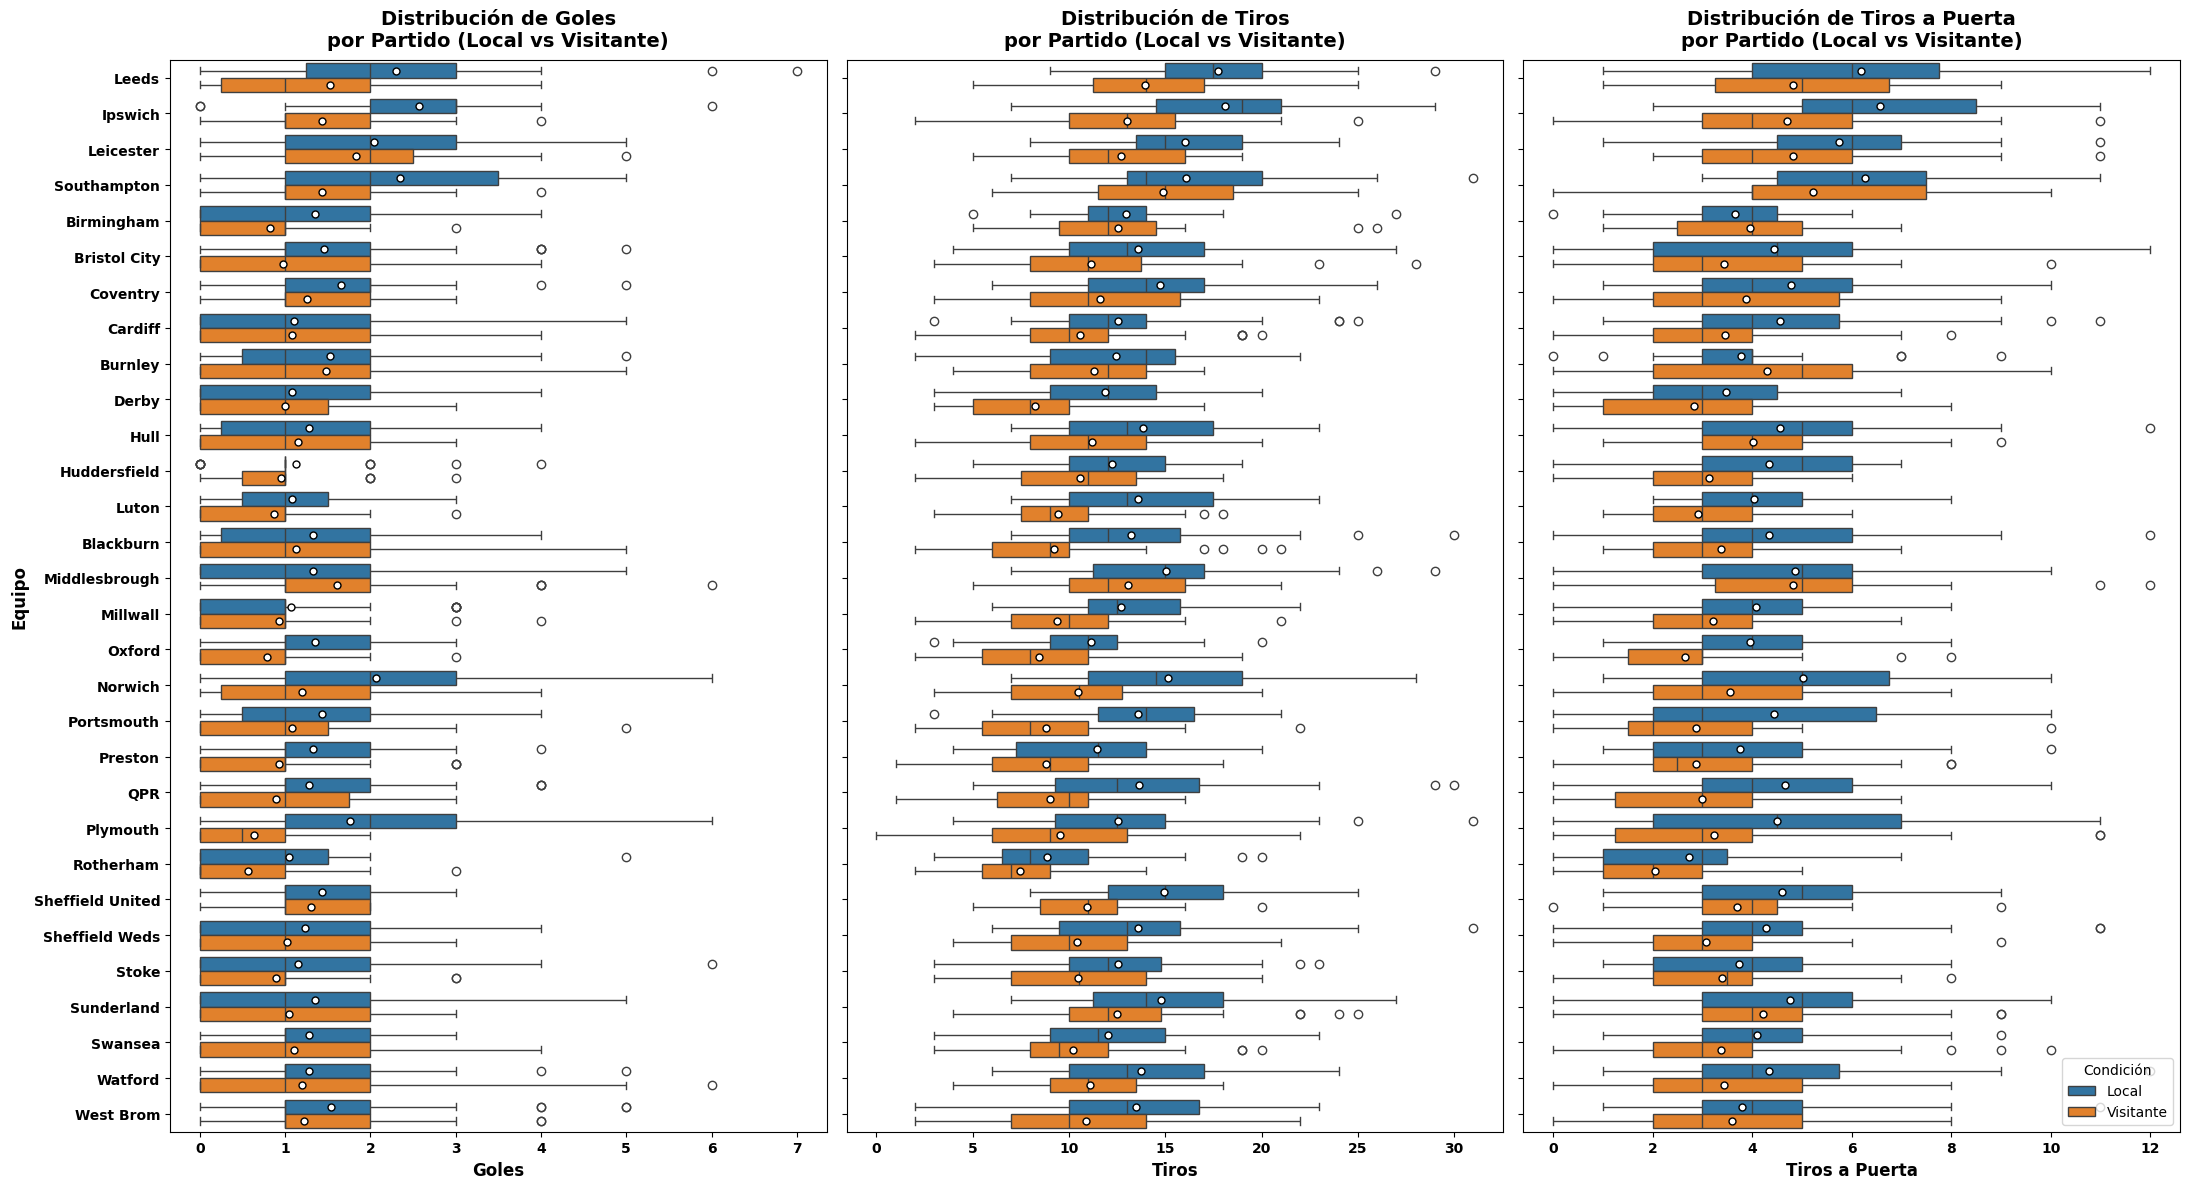

In [4]:
# Preparar los datos: extraer, renombrar y añadir la condición (Local/Visitante)
df_home = df[['HomeTeam', 'FTHG', 'HS', 'HST']].rename(
    columns={'HomeTeam': 'Team', 'FTHG': 'Goles', 'HS': 'Tiros', 'HST': 'Tiros a Puerta'}
)
df_home['Condición'] = 'Local'

df_away = df[['AwayTeam', 'FTAG', 'AS', 'AST']].rename(
    columns={'AwayTeam': 'Team', 'FTAG': 'Goles', 'AS': 'Tiros', 'AST': 'Tiros a Puerta'}
)
df_away['Condición'] = 'Visitante'

# Unir ambos DataFrames
df_stats = pd.concat([df_home, df_away], ignore_index=True)

# Ordenar equipos por la mediana general de goles 
team_order = df_stats.groupby('Team')['Goles'].median().sort_values(ascending=False).index

# Configurar la figura con 3 subplots (1 fila, 3 columnas)
metrics = ['Goles', 'Tiros', 'Tiros a Puerta']
palette_colors = {'Local': '#1f77b4', 'Visitante': '#ff7f0e'} 

fig, axes = plt.subplots(1, 3, figsize=(22, 12), sharey=True)

# Bucle para generar los boxplots
for i, metric in enumerate(metrics):
    sns.boxplot(
        data=df_stats,
        x=metric,
        y='Team',
        hue='Condición',
        order=team_order,
        palette=palette_colors,
        ax=axes[i],
        showmeans=True, 
        meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"5"}
    )
    
    axes[i].set_title(f'Distribución de {metric}\npor Partido (Local vs Visitante)', 
                      fontsize=14, pad=10, fontweight='bold')
    axes[i].set_xlabel(metric, fontsize=12, fontweight='bold')
    
    plt.setp(axes[i].get_xticklabels(), fontweight='bold')
    
    if i == 0:
        axes[i].set_ylabel('Equipo', fontsize=12, fontweight='bold')
        # Poner en negrita los nombres de los equipos en el eje Y
        plt.setp(axes[i].get_yticklabels(), fontweight='bold')
    else:
        axes[i].set_ylabel('')
        
    # Limpiar las leyendas redundantes y configurar la final 
    if i < 2:
        axes[i].get_legend().remove()
    else:
        axes[i].legend(title='Condición', loc='lower right')

# Ajustar márgenes generales
plt.tight_layout()
plt.show()

In [5]:
# Preparar los datos de resultados
# Mapeamos los códigos originales (H, D, A) a nombres más descriptivos
result_map = {'H': 'Victoria Local', 'D': 'Empate', 'A': 'Victoria Visitante'}
df_results = df['FTR'].map(result_map).value_counts().reset_index()
df_results.columns = ['Resultado', 'Partidos']

# Calcular porcentajes para mostrar en el gráfico
total_matches = df_results['Partidos'].sum()
df_results['Porcentaje'] = (df_results['Partidos'] / total_matches * 100).round(2)

# Crear la visualización con Plotly
fig = px.bar(
    df_results, 
    x='Resultado', 
    y='Partidos',
    text=df_results['Porcentaje'].apply(lambda x: f'{x}%'), 
    color='Resultado',
    color_discrete_map={
        'Victoria Local': '#1f77b4', 
        'Empate': '#9467bd', 
        'Victoria Visitante': '#ff7f0e'
    },
    title='Distribución Global de Resultados'
)

# Estilizar el gráfico 
fig.update_layout(
    xaxis_title='<b>Resultado del Partido</b>',
    yaxis_title='<b>Número de Partidos</b>',
    title_font=dict(size=20, family='Arial', color='black'),
    template='plotly_white',
    showlegend=False,
    font=dict(family="Arial", size=12, color="black")
)

fig.update_xaxes(tickfont=dict(family='Arial', size=14, color='black'))
fig.update_yaxes(tickfont=dict(family='Arial', size=14, color='black'))

fig.show()

### Ajuste de Parámetros: Robustez mediante la Mediana

Se ha tomado la decisión técnica de utilizar la **mediana** en lugar de la media aritmética para la estimación de los parámetros de fuerza de ataque ($\alpha$) y defensa ($\beta$) en los modelos probabilísticos de Poisson.

#### Justificación Técnica
* **Presencia de Outliers**: Los diagramas de caja revelan una asimetría positiva significativa en la distribución de goles, con valores atípicos (partidos de 4, 5 o más goles) que desplazan la media hacia arriba¡.
* **Suposición de Poisson**: El modelo tradicional de Maher y su extensión de Dixon-Coles asumen que el conteo de goles sigue una distribución de Poisson donde la media es igual a la varianza. La utilización de la mediana actúa como un estimador robusto que evita la sobreestimación del potencial goleador causada por goleadas aisladas.
* **Estabilidad del Modelo**: Al centrar los parámetros en la mediana, se logra una mayor resistencia a las "anomalías" de la jornada, permitiendo que el modelo de **Dixon-Coles** se enfoque en la tendencia central de rendimiento en lugar de en eventos de baja probabilidad.

Esta decisión busca corregir la tendencia de los modelos basados en Poisson a infraestimar marcadores bajos (0-0, 1-1), alineándose con la necesidad de manejar la alta incidencia de empates identificada en el estudio.

In [6]:
# Nos quedamos con la primera temporada y mitad de la segunda para entrenar y con la mitad restante para predecir/validar
df_train = df.iloc[:-190].copy()
df_test = df.iloc[-190:].copy()
df_test

,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,...,AHCh,B365CAHH,B365CAHA,PCAHH,PCAHA,MaxCAHH,MaxCAHA,AvgCAHH,AvgCAHA,Jornada
914,E1,2025-02-05 19:45:00,19:45,Coventry,Leeds,0,2,A,0,2,...,0.75,1.83,2.07,1.84,2.08,1.86,2.11,1.82,2.03,77
915,E1,2025-02-08 12:30:00,12:30,Sunderland,Watford,2,2,D,1,1,...,-1.25,2.08,1.82,2.11,1.82,2.13,1.84,2.06,1.79,77
916,E1,2025-02-08 12:30:00,12:30,West Brom,Sheffield Weds,2,1,H,0,0,...,-0.25,1.83,2.07,1.85,2.07,1.91,2.12,1.83,2.02,77
917,E1,2025-02-08 15:00:00,15:00,Sheffield United,Portsmouth,2,1,H,1,1,...,-1.00,2.03,1.87,2.02,1.88,2.06,1.92,1.99,1.86,31
918,E1,2025-02-08 15:00:00,15:00,Norwich,Derby,1,1,D,0,0,...,-0.75,2.08,1.82,2.08,1.83,2.09,1.95,1.99,1.85,77
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1099,E1,2025-05-03 12:30:00,12:30,Coventry,Middlesbrough,2,0,H,1,0,...,-0.25,1.89,2.01,1.90,2.01,1.90,2.07,1.86,1.99,92
1100,E1,2025-05-03 12:30:00,12:30,Burnley,Millwall,3,1,H,1,1,...,-1.00,1.89,2.01,1.88,2.03,1.91,2.06,1.88,1.97,92
1101,E1,2025-05-03 12:30:00,12:30,Bristol City,Preston,2,2,D,0,1,...,-0.50,1.98,1.92,1.94,1.96,1.99,1.96,1.95,1.90,92
1102,E1,2025-05-03 12:30:00,12:30,Norwich,Cardiff,4,2,H,3,0,...,-1.00,1.86,2.04,1.88,2.03,1.96,2.06,1.86,1.99,92


### Modelo de Maher (1982)
El modelo de Maher establece que el número de goles marcados por el equipo local y el visitante siguen distribuciones de **Poisson independientes**, cuyas medias ($\lambda$) se calculan cruzando la capacidad ofensiva de un equipo ($\alpha$) frente a la capacidad defensiva de su oponente ($\beta$). Su premisa fundamental es la **independencia estocástica**, asumiendo el hecho de que un equipo marque no altera la probabilidad de que el otro lo haga, permitiendo calcular la probabilidad de cualquier marcador exacto mediante el producto simple de sus probabilidades individuales: $P(X=x, Y=y) = P(X=x) \cdot P(Y=y)$

In [7]:
def predict_match_maher(row, params, avg_home_goals, avg_away_goals):
    '''
    Función que predice el resultado del partido a partir de la distribución de Poisson en función de la fuerza de ataque y de defensa de los equipos
    '''
    home = row['HomeTeam']   # equipo local
    away = row['AwayTeam']   # equipo visitante

    # Calcular Goles Esperados

    lambda_home = params.loc[home, 'Alpha_Home'] * params.loc[away, 'Beta_Away'] * avg_home_goals   # goles esperados del local
    lambda_away = params.loc[away, 'Alpha_Away'] * params.loc[home, 'Beta_Home'] * avg_away_goals   # goles esperados del visitante

    # Generar probabilidades de marcadores
    # Probabilidad de marcar k goles (considerando una distribución de Poisson) : poisson.pmf(k, lambda) -> poisson(k, lambda) = (exp(-lambda) * lambda^k) / lambda!
    # poisson.ppf(epsilon, lambda) -> Dado lambda, te dice a partir de que k (número de goles), cubres el (epsilon * 100)% de los casos (considerando una distribución de Poisson)

    epsilon = 0.9999   # Cubriremos al menos el 99.99% de los casos
    max_k_home = poisson.ppf(epsilon, lambda_home)
    max_k_away = poisson.ppf(epsilon, lambda_away)

    # Nos aseguramos de cubrir al menos hasta el máximo de los dos + 1 margen de seguridad
    max_goals = int(max(max_k_home, max_k_away)) + 1

    # Generamos el rango de goles (0, 1, 2... hasta max_goals)
    k_values = np.arange(0, max_goals)

    # Calculamos todas las probabilidades
    prob_h = poisson.pmf(k_values, lambda_home)
    prob_a = poisson.pmf(k_values, lambda_away)

    # Matriz de probabilidades
    # prob_matrix[i][j] es la probabilidad del marcador i-j (Local-Visitante)
    prob_matrix = np.outer(prob_h, prob_a)
    # Re-normalizar para que la suma sea exactamente 1.0
    prob_matrix /= prob_matrix.sum()

    # Sumar probabilidades para 1X2
    # np.tril (triángulo inferior) -> Gana Local (i > j)
    # np.triu (triángulo superior) -> Gana Visitante (i < j)
    # np.diag (diagonal) -> Empate (i = j)

    # Prob Victoria Local (suma de los elementos 'debajo' de la diagonal)
    p_home_win = np.sum(np.tril(prob_matrix, -1))

    # Prob Empate (suma de los elementos de la diagonal)
    p_draw = np.sum(np.diag(prob_matrix))

    # Prob Victoria Visitante (suma de los elementos 'encima' de la diagonal)
    p_away_win = np.sum(np.triu(prob_matrix, 1))

    return pd.Series([p_home_win, p_draw, p_away_win],
                     index=['Prob_Home', 'Prob_Draw', 'Prob_Away'])

In [ ]:
# CÁLCULO DE PARÁMETROS
# Fuerza de ataque = w_goles * goles_mediana / goles_mediana_liga +  w_tiros_a_puerta * tiros_a_puerta_mediana / tiros_a_puerta_mediana_liga + w_tiros_totales * tiros_totales_mediana / tiros_totales_mediana_liga
# Fuerza de defensa = w_goles * goles_mediana_recibidos / goles_mediana_recibidos_liga +  w_tiros_a_puerta * tiros_a_puerta_mediana_recibidos / tiros_a_puerta_mediana_recibidos_liga + w_tiros_totales * tiros_totales_mediana_recibidos / tiros_totales_mediana_recibidos_liga

avg_home_goals = df_train['FTHG'].median()
avg_away_goals = df_train['FTAG'].median()
avg_home_st = df_train['HST'].median()
avg_away_st = df_train['AST'].median()
avg_home_s = df_train['HS'].median()
avg_away_s = df_train['AS'].median()

# Estadísticas en casa y fuera de casa (mediana de goles marcados/recibidos y mediana de disparos realizados/recibidos (a puerta y totales))
home_stats = df_train.groupby('HomeTeam')[['FTHG', 'HST', 'HS', 'FTAG', 'AST', 'AS']].median()
away_stats = df_train.groupby('AwayTeam')[['FTAG', 'AST', 'AS', 'FTHG', 'HST', 'HS']].median()

# Lista global para guardar la historia de la optimización
maher_history = []

# --- OPTIMIZACIÓN AVANZADA DE MAHER ---

def negative_log_likelihood_maher_3weights(opt_params, df_dataset):
    """
    Calcula el error (Log Loss) del modelo Maher variando los pesos de
    Goles / Tiros Puerta / Tiros Totales.
    Optimiza buscando maximizar la probabilidad del resultado REAL (1X2).
    """
    w_g, w_st = opt_params
    w_tot = 1.0 - w_g - w_st

    # Penalización si los pesos son inválidos (negativos)
    if w_g < 0 or w_st < 0 or w_tot < 0:
        return 9999999

    # -- CONSTRUCCIÓN DE PARÁMETROS --
    # Creamos las alfas y betas temporales con los pesos que estamos probando
    params_trial = pd.DataFrame(index=home_stats.index)

    # Fuerza Ataque Local
    params_trial['Alpha_Home'] = (
        (home_stats['FTHG'] / avg_home_goals) * w_g +
        (home_stats['HST'] / avg_home_st) * w_st +
        (home_stats['HS'] / avg_home_s) * w_tot
    )
    # Debilidad Defensa Local
    params_trial['Beta_Home'] = (
        (home_stats['FTAG'] / avg_away_goals) * w_g +
        (home_stats['AST'] / avg_away_st) * w_st +
        (home_stats['AS'] / avg_away_s) * w_tot
    )
    # Fuerza Ataque Visitante
    params_trial['Alpha_Away'] = (
        (away_stats['FTAG'] / avg_away_goals) * w_g +
        (away_stats['AST'] / avg_away_st) * w_st +
        (away_stats['AS'] / avg_away_s) * w_tot
    )
    # Debilidad Defensa Visitante
    params_trial['Beta_Away'] = (
        (away_stats['FTHG'] / avg_home_goals) * w_g +
        (away_stats['HST'] / avg_home_st) * w_st +
        (away_stats['HS'] / avg_home_s) * w_tot
    )

    # -- EVALUACIÓN DEL ERROR EN EL DATASET --
    total_log_likelihood = 0
    count_valid = 0

    # Iteramos por los partidos para ver qué tan bien predicen estos pesos
    for idx, row in df_dataset.iterrows():
        h, a = row['HomeTeam'], row['AwayTeam']
        if h not in params_trial.index or a not in params_trial.index:
            continue

        # Le pasamos los params_trial calculados con los pesos actuales
        probs = predict_match_maher(row, params_trial, avg_home_goals, avg_away_goals)

        p_home = probs['Prob_Home']
        p_draw = probs['Prob_Draw']
        p_away = probs['Prob_Away']

        # Seleccionamos la probabilidad de lo que OCURRIÓ REALMENTE
        if row['FTHG'] > row['FTAG']:
            prob_obs = p_home      # Ganó Local
        elif row['FTHG'] == row['FTAG']:
            prob_obs = p_draw   # Empate
        else:
            prob_obs = p_away   # Ganó Visitante

        # Sumamos el Log negativo
        total_log_likelihood -= np.log(max(prob_obs, 1e-9))
        count_valid += 1   # Contador de partidos válidos

    if count_valid == 0:
        return 9999999

    # Imprimir progreso
    # Referencia Score: 1.10 (33% p - Azar) | 1.06 (35% p - Básico) | 1.00 (37% p - Profesional) | 0.90 (40% p - Élite) | 0.35 (70% p - Utopía)
    score = total_log_likelihood / count_valid   # Media de log-probabilidad por partido
    maher_history.append({
        'Iteration': len(maher_history),
        'w_goles': w_g,
        'w_puerta': w_st,
        'w_totales': w_tot,
        'Score': score
    })
    print(f"Iter: {len(maher_history)} | w:_goles: {w_g:.12f} | w_shots_on_taget: {w_st:.12f} | w_total_shots: {w_tot:.12f} | Score (1X2): {score:.12f}")

    return score

In [ ]:
# EJECUCIÓN DE LA OPTIMIZACIÓN

print("⏳ Buscando los pesos óptimos...")

# Definimos los límites para los 2 pesos (goles y tiros a puerta)
bounds_de = [(0.0, 1.0), (0.0, 1.0)]

# Optimizamos
res_global = differential_evolution(
    negative_log_likelihood_maher_3weights,
    bounds=bounds_de,
    args=(df_train,),
    strategy='best1bin',
    maxiter=1000,
    popsize=15,
    tol=0.001,
    polish=True,
)

# Extraemos los mejores pesos
best_w_g = res_global.x[0]
best_w_st = res_global.x[1]
best_w_tot = 1.0 - best_w_g - best_w_st
final_log_score = res_global.fun 

# Log score final

print("✅ Optimización Completada.")
print(f"🎯 Pesos Óptimos -> Goles: {best_w_g:.20f} | Tiros Puerta: {best_w_st:.20f} | Tiros Totales: {best_w_tot:.20f} | Score final: {final_log_score}")

⏳ Buscando los pesos óptimos...
Iter: 1 | w:_goles: 0.379973851609 | w_shots_on_taget: 0.080623753958 | w_total_shots: 0.539402394433 | Score (1X2): 1.000515208238
Iter: 2 | w:_goles: 0.460432884715 | w_shots_on_taget: 0.120597438382 | w_total_shots: 0.418969676903 | Score (1X2): 0.997198522168
Iter: 3 | w:_goles: 0.876591468188 | w_shots_on_taget: 0.005592071184 | w_total_shots: 0.117816460628 | Score (1X2): 1.011703088795
Iter: 4 | w:_goles: 0.311869284740 | w_shots_on_taget: 0.671346775252 | w_total_shots: 0.016783940008 | Score (1X2): 1.006188737469
Iter: 5 | w:_goles: 0.059590228816 | w_shots_on_taget: 0.644838326826 | w_total_shots: 0.295571444358 | Score (1X2): 1.027970499007
Iter: 6 | w:_goles: 0.483484662779 | w_shots_on_taget: 0.189566975518 | w_total_shots: 0.326948361703 | Score (1X2): 0.996239661254
Iter: 7 | w:_goles: 0.080398171663 | w_shots_on_taget: 0.160638726776 | w_total_shots: 0.758963101561 | Score (1X2): 1.024253651163
Iter: 8 | w:_goles: 0.510547264038 | w_shots

In [20]:
# Para no volver a optimizar
best_w_g = 0.57189510421344857960
best_w_st = 0.27188821202493684837
best_w_tot = 1.0 - best_w_g - best_w_st

In [21]:
# VISUALIZACIÓN DINÁMICA

df_viz = pd.DataFrame(maher_history)

# Creamos el gráfico 3D
fig = px.scatter_3d(
    df_viz,
    x='w_goles',
    y='w_puerta',
    z='Score',
    hover_data=['w_totales'],
    title='<b>Dinámica de Optimización: Búsqueda del Score Mínimo</b>',
    labels={'w_goles': 'Peso Goles', 'w_puerta': 'Peso Tiros A Puerta', 'Score': 'Log Loss (Score)'},
    color_continuous_scale='Viridis'
)

# Añadimos una línea que conecte los puntos para ver el camino
fig.update_traces(mode='lines+markers', marker=dict(size=4))

# Marcamos el punto final (óptimo) en rojo
best_point = df_viz.iloc[df_viz['Score'].idxmin()]
fig.add_scatter3d(
    x=[best_point['w_goles']],
    y=[best_point['w_puerta']],
    z=[best_point['Score']],
    mode='markers',
    marker=dict(size=4, color='red'),
    name='Óptimo'
)

# Configuración de los rangos de los ejes
fig.update_layout(
    scene=dict(
        xaxis=dict(title='Peso Goles', range=[0, 1]),
        yaxis=dict(title='Peso Tiros Puerta', range=[0, 1]),
        zaxis=dict(title='Log Loss (Score)', range=[final_log_score * 0.98, final_log_score * 1.06]),
        camera=dict(
            eye=dict(x=1, y=1, z=0.75)
        )
    ),
    legend=dict(
        x=0.6,
        y=0.9,
        xanchor='left',
        yanchor='top',
        bgcolor='rgba(255, 255, 255, 0.5)'
    ),
    margin=dict(l=0, r=0, b=0, t=60)
)

fig.show()

In [22]:
# --- PREDICCIÓN ROLLING WINDOW (MAHER) ---

# Definimos las listas de equipos especiales
relegated_from_pl = []
promoted_from_l1 = []

# Función auxiliar
def calculate_current_params(df_history, w_g, w_st, w_tot):

    #FILTRO DE FECHA: Definir inicio de la temporada 24/25
    start_date_24_25 = pd.to_datetime('2024-08-01')

    # Nos quedamos SOLO con los partidos de esta temporada
    current_season_df = df_history[df_history['Date'] > start_date_24_25].copy()

    if len(current_season_df) == 0:
        # Fallback de seguridad por si acaso
        current_season_df = df_history.copy()

    avg_h_g = current_season_df['FTHG'].median()
    avg_a_g = current_season_df['FTAG'].median()
    avg_h_st = current_season_df['HST'].median()
    avg_a_st = current_season_df['AST'].median()
    avg_h_s = current_season_df['HS'].median()
    avg_a_s = current_season_df['AS'].median()

    h_stats = current_season_df.groupby('HomeTeam')[['FTHG', 'HST', 'HS', 'FTAG', 'AST', 'AS']].median()
    a_stats = current_season_df.groupby('AwayTeam')[['FTAG', 'AST', 'AS', 'FTHG', 'HST', 'HS']].median()

    p = pd.DataFrame(index=h_stats.index)
    p['Alpha_Home'] = (h_stats['FTHG']/avg_h_g)*w_g + (h_stats['HST']/avg_h_st)*w_st + (h_stats['HS']/avg_h_s)*w_tot
    p['Beta_Home']  = (h_stats['FTAG']/avg_a_g)*w_g + (h_stats['AST']/avg_a_st)*w_st + (h_stats['AS']/avg_a_s)*w_tot
    p['Alpha_Away'] = (a_stats['FTAG']/avg_a_g)*w_g + (a_stats['AST']/avg_a_st)*w_st + (a_stats['AS']/avg_a_s)*w_tot
    p['Beta_Away']  = (a_stats['FTHG']/avg_h_g)*w_g + (a_stats['HST']/avg_h_st)*w_st + (a_stats['HS']/avg_h_s)*w_tot

    return p, avg_h_g, avg_a_g

# Bucle Principal
history_df = df_train.copy()
dynamic_predictions = []

print(f"⏳ Iniciando validación dinámica sobre {len(df_test)} partidos...")

for idx, row in df_test.iterrows():
    # Recalcular parámetros con todo lo anterior
    current_params, curr_h, curr_a = calculate_current_params(history_df, best_w_g, best_w_st, best_w_tot)

    # Creamos una copia temporal para este partido para no ensuciar el histórico global
    match_params = current_params.copy()

    h_team = row['HomeTeam']
    a_team = row['AwayTeam']

    # Calculamos la mediana de la liga actual (para rellenar huecos)
    league_avg = match_params.median()

    # LÓGICA HOME TEAM (Si no existe, lo creamos sintéticamente)
    if h_team not in match_params.index:
        vals = league_avg.copy()
        if h_team in relegated_from_pl: # Viene de arriba (Fuerte)
            vals['Alpha_Home'] *= 1.20
            vals['Beta_Home'] *= 0.80
            vals['Alpha_Away'] *= 1.15
            vals['Beta_Away'] *= 0.85
        elif h_team in promoted_from_l1: # Viene de abajo (Débil)
            vals['Alpha_Home'] *= 0.85
            vals['Beta_Home'] *= 1.15
            vals['Alpha_Away'] *= 0.80
            vals['Beta_Away'] *= 1.20
        # Insertamos en el match_params temporal
        match_params.loc[h_team] = vals

    # LÓGICA AWAY TEAM (Si no existe, lo creamos sintéticamente)
    if a_team not in match_params.index:
        vals = league_avg.copy()
        if a_team in relegated_from_pl:
            vals['Alpha_Home'] *= 1.20
            vals['Beta_Home'] *= 0.80
            vals['Alpha_Away'] *= 1.20
            vals['Beta_Away'] *= 0.80
        elif a_team in promoted_from_l1:
            vals['Alpha_Home'] *= 0.80
            vals['Beta_Home'] *= 1.20
            vals['Alpha_Away'] *= 0.80
            vals['Beta_Away'] *= 1.20
        # Insertamos en el match_params temporal
        match_params.loc[a_team] = vals

    # --- FIN DE LÓGICA INYECTADA ---

    # Predecir (Usamos match_params en vez de current_params para usar los equipos sintéticos si hiciera falta)
    pred = predict_match_maher(row, match_params, curr_h, curr_a)

    dynamic_predictions.append(pred)

    # Actualizar Historial
    history_df = pd.concat([history_df, row.to_frame().T])

# Guardar resultados (MANTENIDO DEL CÓDIGO 1)
predictions = pd.DataFrame(dynamic_predictions, index=df_test.index)
odds_targets = ['B365H', 'B365D', 'B365A', 'PSH', 'PSD', 'PSA']
cols_to_keep = ['Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG'] + odds_targets
results = pd.concat([df_test[cols_to_keep], predictions], axis=1)

# Evaluar Hits (MANTENIDO DEL CÓDIGO 1)
conditions = [results['FTHG'] > results['FTAG'], results['FTAG'] > results['FTHG']]
real_outcome = np.select(conditions, ['Prob_Home', 'Prob_Away'], default='Prob_Draw')
predicted_outcome = results[['Prob_Home', 'Prob_Draw', 'Prob_Away']].idxmax(axis=1)
results['Hit'] = (real_outcome == predicted_outcome).astype(int)

print("✅ Validación Maher Mejorado completada.")

print("📊 Resultados de las últimas jornadas:")
cols_show = ['Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'Prob_Home', 'Prob_Draw', 'Prob_Away', 'Hit']
display(results[cols_show])

⏳ Iniciando validación dinámica sobre 190 partidos...
✅ Validación Maher Mejorado completada.
📊 Resultados de las últimas jornadas:


,Date,HomeTeam,AwayTeam,FTHG,FTAG,Prob_Home,Prob_Draw,Prob_Away,Hit
914,2025-02-05 19:45:00,Coventry,Leeds,0,2,0.220906,0.261881,0.517213,1
915,2025-02-08 12:30:00,Sunderland,Watford,2,2,0.803733,0.129182,0.067086,0
916,2025-02-08 12:30:00,West Brom,Sheffield Weds,2,1,0.416160,0.337685,0.246155,1
917,2025-02-08 15:00:00,Sheffield United,Portsmouth,2,1,0.745561,0.197946,0.056493,1
918,2025-02-08 15:00:00,Norwich,Derby,1,1,0.726168,0.155373,0.118459,0
...,...,...,...,...,...,...,...,...,...
1099,2025-05-03 12:30:00,Coventry,Middlesbrough,2,0,0.474483,0.243489,0.282028,1
1100,2025-05-03 12:30:00,Burnley,Millwall,3,1,0.499984,0.366493,0.133523,1
1101,2025-05-03 12:30:00,Bristol City,Preston,2,2,0.670343,0.194509,0.135148,0
1102,2025-05-03 12:30:00,Norwich,Cardiff,4,2,0.614600,0.207225,0.178175,1


### Modelo de Dixon-Coles (1997)
El modelo de Dixon-Coles es una extensión dinámica que introduce dos mejoras críticas: un **factor de peso temporal** ($\xi$) para dar mayor relevancia a los resultados recientes y un **parámetro de dependencia** ($\rho$) que corrige la infraestimación de los marcadores bajos (0-0, 1-1, 1-0, 0-1). Este modelo utiliza una función de corrección $\tau$ para ajustar la distribución de Poisson en estos casos específicos, eliminando la asunción de independencia y logrando una estimación de la probabilidad de empate mucho más fiel a la realidad histórica del fútbol profesional.

In [15]:
df_Dixon = df.copy()

df_Dixon_train = df_Dixon.iloc[:-190].copy()
df_Dixon_test = df_Dixon.iloc[-190:].copy()

In [16]:
def get_params_at_time_enhanced(target_jornada, xi, df_history, w_g, w_st, w_tot):
    mask = df_history['Jornada'] < target_jornada
    past_matches = df_history[mask].copy()

    if len(past_matches) == 0:
        return None, 0, 0

    # CLIPPER DINÁMICO (MÉTODO DE TUKEY - IQR)
    # Calculamos los límites para los goles en casa (FTHG)
    q1_h = past_matches['FTHG'].quantile(0.25)
    q3_h = past_matches['FTHG'].quantile(0.75)
    iqr_h = q3_h - q1_h
    upper_fence_h = q3_h + 1.5 * iqr_h

    # Calculamos los límites para los goles fuera (FTAG)
    q1_a = past_matches['FTAG'].quantile(0.25)
    q3_a = past_matches['FTAG'].quantile(0.75)
    iqr_a = q3_a - q1_a
    upper_fence_a = q3_a + 1.5 * iqr_a

    # Aplicamos el corte dinámico (los outliers se "achatan" hasta el límite superior)
    past_matches['FTHG_lim'] = past_matches['FTHG'].clip(upper=upper_fence_h)
    past_matches['FTAG_lim'] = past_matches['FTAG'].clip(upper=upper_fence_a)

    # Vectorización del Peso Temporal (Decaimiento exponencial de Dixon-Coles)
    diff = target_jornada - past_matches['Jornada'] - 1
    past_matches['Tw'] = np.exp(-xi * diff)

    # Multiplicamos las estadísticas por su peso temporal
    cols_stats = ['FTHG_lim', 'HST', 'HS', 'FTAG_lim', 'AST', 'AS']
    for col in cols_stats:
        past_matches[col + '_w'] = past_matches[col] * past_matches['Tw']

    # Agrupaciones vectorizadas (Suma de los valores ponderados y Suma de los pesos)
    cols_w = [c + '_w' for c in cols_stats]
    
    home_sums = past_matches.groupby('HomeTeam')[cols_w + ['Tw']].sum()
    away_sums = past_matches.groupby('AwayTeam')[cols_w + ['Tw']].sum()

    # Promedios Globales de la Liga (Suma total ponderada / Peso total)
    total_tw = past_matches['Tw'].sum()
    avg_h_g = past_matches['FTHG_lim_w'].sum() / total_tw
    avg_a_g = past_matches['FTAG_lim_w'].sum() / total_tw
    avg_h_st = past_matches['HST_w'].sum() / total_tw
    avg_a_st = past_matches['AST_w'].sum() / total_tw
    avg_h_tot = past_matches['HS_w'].sum() / total_tw
    avg_a_tot = past_matches['AS_w'].sum() / total_tw

    # Unir y calcular las Medias Ponderadas por equipo
    all_teams = home_sums.index.union(away_sums.index)
    
    home_sums = home_sums.reindex(all_teams).fillna({'Tw': 0})
    away_sums = away_sums.reindex(all_teams).fillna({'Tw': 0})

    stats_h = pd.DataFrame(index=all_teams)
    stats_h['FTHG'] = (home_sums['FTHG_lim_w'] / home_sums['Tw']).replace([np.inf, -np.inf, np.nan], avg_h_g)
    stats_h['HST']  = (home_sums['HST_w'] / home_sums['Tw']).replace([np.inf, -np.inf, np.nan], avg_h_st)
    stats_h['HS']   = (home_sums['HS_w'] / home_sums['Tw']).replace([np.inf, -np.inf, np.nan], avg_h_tot)
    stats_h['FTAG'] = (home_sums['FTAG_lim_w'] / home_sums['Tw']).replace([np.inf, -np.inf, np.nan], avg_a_g)
    stats_h['AST']  = (home_sums['AST_w'] / home_sums['Tw']).replace([np.inf, -np.inf, np.nan], avg_a_st)
    stats_h['AS']   = (home_sums['AS_w'] / home_sums['Tw']).replace([np.inf, -np.inf, np.nan], avg_a_tot)

    stats_a = pd.DataFrame(index=all_teams)
    stats_a['FTAG'] = (away_sums['FTAG_lim_w'] / away_sums['Tw']).replace([np.inf, -np.inf, np.nan], avg_a_g)
    stats_a['AST']  = (away_sums['AST_w'] / away_sums['Tw']).replace([np.inf, -np.inf, np.nan], avg_a_st)
    stats_a['AS']   = (away_sums['AS_w'] / away_sums['Tw']).replace([np.inf, -np.inf, np.nan], avg_a_tot)
    stats_a['FTHG'] = (away_sums['FTHG_lim_w'] / away_sums['Tw']).replace([np.inf, -np.inf, np.nan], avg_h_g)
    stats_a['HST']  = (away_sums['HST_w'] / away_sums['Tw']).replace([np.inf, -np.inf, np.nan], avg_h_st)
    stats_a['HS']   = (away_sums['HS_w'] / away_sums['Tw']).replace([np.inf, -np.inf, np.nan], avg_h_tot)

    # Construcción de Parámetros combinando los 3 pesos fijos
    params = pd.DataFrame(index=all_teams)
    params['Alpha_Home'] = (stats_h['FTHG']/avg_h_g)*w_g + (stats_h['HST']/avg_h_st)*w_st + (stats_h['HS']/avg_h_tot)*w_tot
    params['Beta_Home']  = (stats_h['FTAG']/avg_a_g)*w_g + (stats_h['AST']/avg_a_st)*w_st + (stats_h['AS']/avg_a_tot)*w_tot
    params['Alpha_Away'] = (stats_a['FTAG']/avg_a_g)*w_g + (stats_a['AST']/avg_a_st)*w_st + (stats_a['AS']/avg_a_tot)*w_tot
    params['Beta_Away']  = (stats_a['FTHG']/avg_h_g)*w_g + (stats_a['HST']/avg_h_st)*w_st + (stats_a['HS']/avg_h_tot)*w_tot

    return params, avg_h_g, avg_a_g

In [17]:
def predict_match_dixon_coles(row, params, avg_home_goals, avg_away_goals, rho):
    '''
    Función que predice el resultado del partido usando el modelo Dixon-Coles.
    Incorpora la dependencia entre goles (rho) para ajustar probabilidades de marcadores bajos.
    '''
    home = row['HomeTeam']   # equipo local
    away = row['AwayTeam']   # equipo visitante

    # Calcular Goles Esperados (Lambdas)
    lambda_home = params.loc[home, 'Alpha_Home'] * params.loc[away, 'Beta_Away'] * avg_home_goals
    lambda_away = params.loc[away, 'Alpha_Away'] * params.loc[home, 'Beta_Home'] * avg_away_goals

    # Generar probabilidades de marcadores
    # Calculamos hasta un número seguro de goles
    epsilon = 0.9999
    max_k_home = poisson.ppf(epsilon, lambda_home)
    max_k_away = poisson.ppf(epsilon, lambda_away)
    max_goals = int(max(max_k_home, max_k_away, 1)) + 1

    # Rango de goles
    k_values = np.arange(0, max_goals)

    # Calculamos probabilidades base (Poisson Independiente)
    prob_h = poisson.pmf(k_values, lambda_home)
    prob_a = poisson.pmf(k_values, lambda_away)

    # Matriz de probabilidades INICIAL
    # prob_matrix[i][j] es la probabilidad del marcador i-j
    prob_matrix = np.outer(prob_h, prob_a)

    # --- CORRECCIÓN DIXON-COLES ---
    # Ajustamos solo los marcadores bajos (0-0, 1-0, 0-1, 1-1) usando rho y tau

    # Definimos la función de corrección tau para los 4 casos específicos
    # Caso 0-0
    prob_matrix[0, 0] *= (1 - lambda_home * lambda_away * rho)
    # Caso 0-1
    prob_matrix[0, 1] *= (1 + lambda_home * rho)
    # Caso 1-0
    prob_matrix[1, 0] *= (1 + lambda_away * rho)
    # Caso 1-1
    prob_matrix[1, 1] *= (1 - rho)

    # Normalización de seguridad (por si rho genera valores negativos extremos raros)
    prob_matrix = np.maximum(prob_matrix, 0)
    # Re-normalizar para que la suma sea exactamente 1.0
    prob_matrix /= prob_matrix.sum()

    # Sumar probabilidades para 1X2

    # Prob Victoria Local (suma triángulo inferior)
    p_home_win = np.sum(np.tril(prob_matrix, -1))

    # Prob Empate (suma diagonal)
    p_draw = np.sum(np.diag(prob_matrix))

    # Prob Victoria Visitante (suma triángulo superior)
    p_away_win = np.sum(np.triu(prob_matrix, 1))

    return pd.Series([p_home_win, p_draw, p_away_win],
                     index=['Prob_Home', 'Prob_Draw', 'Prob_Away'])

In [18]:
n = 0

In [ ]:
# FUNCIÓN DE COSTE OPTIMIZADA (Xi, Rho)
# Utilizamos los pesos fijos obtenidos previamente en el modelo de Maher
# -------------------------------------------------------------------------

try:
    n
except NameError:
    n = 0

def negative_log_likelihood_dixon_enhanced(opt_params, df_dataset, best_w_g, best_w_st, best_w_tot):
    global n
    # Desempaquetamos SOLO los 2 parámetros que vamos a optimizar
    xi_trial, rho_trial = opt_params

    # Penalizaciones lógicas
    if xi_trial < 0 or abs(rho_trial) > 1.0:
        return 9999999

    total_log_likelihood = 0
    count_valid = 0

    # Iteramos por los partidos históricos (Train)
    for idx, row in df_dataset.iterrows():
        t = row['Jornada']

        # Calculamos parámetros dinámicos en T usando los pesos fijos
        params_t, avg_h, avg_a = get_params_at_time_enhanced(
            t, xi_trial, df_dataset, best_w_g, best_w_st, best_w_tot
        )

        if params_t is None:
            continue

        h_team, a_team = row['HomeTeam'], row['AwayTeam']
        if h_team not in params_t.index or a_team not in params_t.index:
            continue

        # Predecimos usando la función de Dixon-Coles
        probs = predict_match_dixon_coles(row, params_t, avg_h, avg_a, rho_trial)

        p_home = probs['Prob_Home']
        p_draw = probs['Prob_Draw']
        p_away = probs['Prob_Away']

        # Calculamos probabilidad del resultado real
        if row['FTHG'] > row['FTAG']:
            prob_obs = p_home
        elif row['FTHG'] == row['FTAG']:
            prob_obs = p_draw
        else:
            prob_obs = p_away

        total_log_likelihood -= np.log(max(prob_obs, 1e-9))
        count_valid += 1

    if count_valid == 0:
        return 9999999

    # Imprimir progreso
    n += 1
    score = total_log_likelihood / count_valid   
    
    print(f"Iter: {n} | Xi: {xi_trial:.6f} | Rho: {rho_trial:.6f} | Score: {score:.8f}")

    return total_log_likelihood

In [ ]:
# EJECUCIÓN DE LA OPTIMIZACIÓN
# -------------------------------------------------------------------------
print("⏳ Iniciando optimización Dixon-Coles (Xi, Rho)...")

# Límites:
bounds = ((0.0, 0.1), (-0.2, 0.2))

# Ejecutamos la optimización global
res_dixon = differential_evolution(
    negative_log_likelihood_dixon_enhanced,
    bounds=bounds,
    args=(df_Dixon_train, best_w_g, best_w_st, best_w_tot),
    strategy='best1bin',
    maxiter=1500,
    popsize=20,
    tol=0.001,
    polish=True,
)

n = 0

# Resultados
best_xi = res_dixon.x[0]
best_rho = res_dixon.x[1]
final_log_score_dixon = res_global.fun 


print("\n✅ ¡Optimización Dixon-Coles Completada!")
print(f"🧠 Memoria (Xi): {best_xi:.20f}")
print(f"🔗 Dependencia goles bajos (Rho): {best_rho:.20f}")
print(f"🎯 Score (Log-Likelihood por partido): {final_log_score_dixon:.6f}")

⏳ Iniciando optimización Dixon-Coles (Xi, Rho)...
Iter: 1 | Xi: 0.042294 | Rho: -0.016838 | Score: 1.06034312
Iter: 2 | Xi: 0.025277 | Rho: 0.180329 | Score: 1.06219291
Iter: 3 | Xi: 0.005837 | Rho: 0.031901 | Score: 1.05700578
Iter: 4 | Xi: 0.067441 | Rho: 0.056361 | Score: 1.06405162
Iter: 5 | Xi: 0.050180 | Rho: -0.079680 | Score: 1.06290322
Iter: 6 | Xi: 0.064708 | Rho: -0.084366 | Score: 1.06551025
Iter: 7 | Xi: 0.096484 | Rho: -0.138587 | Score: 1.07413073
Iter: 8 | Xi: 0.097637 | Rho: 0.171157 | Score: 1.07218434
Iter: 9 | Xi: 0.069575 | Rho: -0.114210 | Score: 1.06755662
Iter: 10 | Xi: 0.036009 | Rho: 0.197619 | Score: 1.06420260
Iter: 11 | Xi: 0.090288 | Rho: 0.069020 | Score: 1.06821541
Iter: 12 | Xi: 0.094860 | Rho: 0.156331 | Score: 1.07108753
Iter: 13 | Xi: 0.080725 | Rho: -0.162239 | Score: 1.07216575
Iter: 14 | Xi: 0.047285 | Rho: -0.005637 | Score: 1.06092880
Iter: 15 | Xi: 0.057513 | Rho: 0.161579 | Score: 1.06513979
Iter: 16 | Xi: 0.028354 | Rho: -0.042295 | Score: 1.

In [34]:
# Para no volver a correr la simulación
best_xi = 0.00215250079835300383
best_rho = 0.01863666423518635026
best_w_g_dixon = best_w_g
best_w_st_dixon = best_w_st
best_w_tot_dixon = best_w_tot

In [35]:
# PREDICCIÓN ITERATIVA (ROLLING WINDOW) EN EL TEST SET

rolling_predictions = []

# Iteramos por cada partido del test set
for idx, row in df_Dixon_test.iterrows():
    # El momento de la predicción es el día del partido
    target_time = row['Jornada']

    # CLAVE: Usamos 'df_Dixon' (todo el dataset) como historial.
    # La función 'get_params_at_time' filtrará automáticamente (Jornada < target_time), por lo que incluirá el train set + los partidos de test que ya se hayan jugado antes de este día.
    current_params, c_avg_h, c_avg_a = get_params_at_time_enhanced(
        target_time,
        best_xi,
        df_Dixon,
        best_w_g_dixon,
        best_w_st_dixon,
        best_w_tot_dixon
    )

    # Predecimos usando los parámetros actualizados a día de hoy
    pred = predict_match_dixon_coles(row, current_params, c_avg_h, c_avg_a, best_rho)

    rolling_predictions.append(pred)

# Convertimos la lista de predicciones en DataFrame
predictions_dixon = pd.DataFrame(rolling_predictions, index=df_Dixon_test.index)

# Unimos con los datos originales para evaluación
results_dixon = pd.concat([df_Dixon_test[cols_to_keep], predictions_dixon], axis=1)

# Calculamos el Hit (Acierto del ganador)
outcome_conditions = [
    results_dixon['FTHG'] > results_dixon['FTAG'],
    results_dixon['FTAG'] > results_dixon['FTHG']
]
real_outcome = np.select(outcome_conditions, ['Prob_Home', 'Prob_Away'], default='Prob_Draw')
predicted_outcome = results_dixon[['Prob_Home', 'Prob_Draw', 'Prob_Away']].idxmax(axis=1)

results_dixon['Hit'] = (real_outcome == predicted_outcome).astype(int)

In [36]:
print("📊 Resultados de las últimas jornadas:")
display(results_dixon[cols_show])

📊 Resultados de las últimas jornadas:


,Date,HomeTeam,AwayTeam,FTHG,FTAG,Prob_Home,Prob_Draw,Prob_Away,Hit
914,2025-02-05 19:45:00,Coventry,Leeds,0,2,0.279357,0.254658,0.465985,1
915,2025-02-08 12:30:00,Sunderland,Watford,2,2,0.502327,0.240092,0.257581,0
916,2025-02-08 12:30:00,West Brom,Sheffield Weds,2,1,0.549591,0.266340,0.184069,1
917,2025-02-08 15:00:00,Sheffield United,Portsmouth,2,1,0.873034,0.105562,0.021404,1
918,2025-02-08 15:00:00,Norwich,Derby,1,1,0.633007,0.202749,0.164244,0
...,...,...,...,...,...,...,...,...,...
1099,2025-05-03 12:30:00,Coventry,Middlesbrough,2,0,0.391244,0.234120,0.374637,1
1100,2025-05-03 12:30:00,Burnley,Millwall,3,1,0.513336,0.335972,0.150692,1
1101,2025-05-03 12:30:00,Bristol City,Preston,2,2,0.528274,0.268852,0.202873,0
1102,2025-05-03 12:30:00,Norwich,Cardiff,4,2,0.551224,0.220633,0.228143,1


### Modelos de Baboota-Kaur (2018)

Este enfoque propone el uso de **Random Forest** y **Gradient Boosting** para abordar la predicción de resultados como un problema de **clasificación ternaria** (Victoria Local, Empate, Victoria Visitante). A diferencia de modelos estadísticos simples, estos algoritmos de aprendizaje supervisado capturan relaciones complejas mediante una **ingeniería de características** avanzada. Entre sus innovaciones críticas se encuentra el factor **Form**, un coeficiente dinámico que captura la dependencia temporal y la fuerza relativa de los oponentes, donde el equipo ganador "roba" una fracción de la forma del perdedor.

El modelo utiliza un hiperparámetro $k$ para promediar el rendimiento reciente en métricas como goles, córneres y tiros a puerta , además de emplear **diferenciales (Class B features)** que mejoran la distribución univariada y reducen la dimensionalidad del espacio de características[cite: 265, 266, 267]. Mientras que **Random Forest** utiliza el principio de *bagging* para construir árboles no correlacionados y reducir la varianza, el modelo de **Gradient Boosting** emplea un proceso secuencial de mejora de errores (*boosting*).

In [27]:
df_Baboota = df.copy()

k = 5          # Ventana de partidos para la media
gamma = 0.33   # Fracción de "robo" de forma del paper

# Inicializar diccionarios para guardar el historial temporal de cada equipo
# (Se guarda el historial GLOBAL reciente del equipo, tanto de local como visitante)
teams = pd.concat([df_Baboota['HomeTeam'], df_Baboota['AwayTeam']]).unique()
team_stats = {team: {
    'GS': [], 'GC': [], 'SOT': [], 'Corners': [], 'Scores': [], 'Form': 1.0, 'GD': 0
} for team in teams}

features_list_Baboota = []

# Bucle cronológico partido a partido
for idx, row in df_Baboota.iterrows():
    h_team = row['HomeTeam']
    a_team = row['AwayTeam']
    
    # Función auxiliar para calcular medias y rachas de los últimos k partidos
    def get_past_stats(team, k_val):
        stats = team_stats[team]
        gs_seq = cast(Sequence[float], stats['GS'])
        if len(gs_seq) < k_val:
            return [np.nan] * 5 # Si no hay suficientes partidos, devuelve nulos
        
        last_gs = gs_seq[-k_val:]
        last_sot = cast(Sequence[float], stats['SOT'])[-k_val:]
        last_corners = cast(Sequence[float], stats['Corners'])[-k_val:]
        last_scores = cast(Sequence[int], stats['Scores'])[-k_val:]
        
        gs_avg = np.mean(last_gs)
        sot_avg = np.mean(last_sot)
        corn_avg = np.mean(last_corners)
        
        streak = np.sum(last_scores) / (3 * k_val)
        
        # Weighted streak (peso 1 al más antiguo, peso k al más reciente)
        weights = np.arange(1, k_val + 1)
        w_streak = np.sum(np.array(last_scores) * weights) / (3 * (k_val * (k_val + 1) / 2))
        
        return [gs_avg, sot_avg, corn_avg, streak, w_streak]

    # -- EXTRAER VARIABLES ANTES DE JUGAR EL PARTIDO --
    h_features = get_past_stats(h_team, k)
    a_features = get_past_stats(a_team, k)
    
    features_list_Baboota.append({
        'H_GS_avg': h_features[0], 'H_SOT_avg': h_features[1], 'H_Corn_avg': h_features[2], 'H_St': h_features[3], 'H_WSt': h_features[4],
        'A_GS_avg': a_features[0], 'A_SOT_avg': a_features[1], 'A_Corn_avg': a_features[2], 'A_St': a_features[3], 'A_WSt': a_features[4],
        'H_Form': team_stats[h_team]['Form'], 'A_Form': team_stats[a_team]['Form'],
        'H_GD': team_stats[h_team]['GD'], 'A_GD': team_stats[a_team]['GD']
    })
    
    # -- ACTUALIZAR HISTORIAL CON EL RESULTADO DEL PARTIDO ACTUAL --
    h_gs, a_gs = row['FTHG'], row['FTAG']
    
    # Puntuación para la racha
    if row['FTR'] == 'H':
        h_score, a_score = 3, 0
    elif row['FTR'] == 'A':
        h_score, a_score = 0, 3
    else:
        h_score, a_score = 1, 1
        
    # Actualizar listas
    cast(list[float], team_stats[h_team]['GS']).append(float(h_gs))
    cast(list[float], team_stats[h_team]['SOT']).append(float(row['HST']))
    cast(list[float], team_stats[h_team]['Corners']).append(float(row['HC']))
    cast(list[int], team_stats[h_team]['Scores']).append(int(h_score))
    team_stats[h_team]['GD'] += (h_gs - a_gs)
    
    cast(list[float], team_stats[a_team]['GS']).append(float(a_gs))
    cast(list[float], team_stats[a_team]['SOT']).append(float(row['AST']))
    cast(list[float], team_stats[a_team]['Corners']).append(float(row['AC']))
    cast(list[int], team_stats[a_team]['Scores']).append(int(a_score))
    team_stats[a_team]['GD'] += (a_gs - h_gs)
    
    # Actualizar la Forma (Algoritmo de robo de forma de Baboota & Kaur)
    old_h_form = float(cast(float, team_stats[h_team]['Form']))
    old_a_form = float(cast(float, team_stats[a_team]['Form']))
    
    if row['FTR'] == 'H':
        team_stats[h_team]['Form'] = old_h_form + gamma * old_a_form
        team_stats[a_team]['Form'] = old_a_form - gamma * old_a_form
    elif row['FTR'] == 'A':
        team_stats[a_team]['Form'] = old_a_form + gamma * old_h_form
        team_stats[h_team]['Form'] = old_h_form - gamma * old_h_form
    else:
        team_stats[h_team]['Form'] = old_h_form - gamma * (old_h_form - old_a_form)
        team_stats[a_team]['Form'] = old_a_form - gamma * (old_a_form - old_h_form)

# Concatenar las nuevas características al DataFrame original
df_features_Baboota = pd.DataFrame(features_list_Baboota)
df_final_Baboota = pd.concat([df_Baboota.reset_index(drop=True), df_features_Baboota], axis=1)

# Crear las Variables Diferenciales (Class B)
df_final_Baboota['Diff_GS_avg'] = df_final_Baboota['H_GS_avg'] - df_final_Baboota['A_GS_avg']
df_final_Baboota['Diff_SOT_avg'] = df_final_Baboota['H_SOT_avg'] - df_final_Baboota['A_SOT_avg']
df_final_Baboota['Diff_Corn_avg'] = df_final_Baboota['H_Corn_avg'] - df_final_Baboota['A_Corn_avg']
df_final_Baboota['Diff_St'] = df_final_Baboota['H_St'] - df_final_Baboota['A_St']
df_final_Baboota['Diff_WSt'] = df_final_Baboota['H_WSt'] - df_final_Baboota['A_WSt']
df_final_Baboota['Diff_Form'] = df_final_Baboota['H_Form'] - df_final_Baboota['A_Form']
df_final_Baboota['Diff_GD'] = df_final_Baboota['H_GD'] - df_final_Baboota['A_GD']

# Eliminar las primeras jornadas (ya que tienen NaN por falta de historial)
df_ml_Baboota = df_final_Baboota.dropna().copy()

# Codificar el Target (FTR) a números para el modelo
map_resultado = {'H': 0, 'D': 1, 'A': 2}
df_ml_Baboota['Target'] = df_ml_Baboota['FTR'].map(map_resultado)

# -- RESUMEN DE LAS VARIABLES FINALES PARA EL MODELO --
variables_prediccion_Baboota = [
    'Diff_GS_avg', 'Diff_SOT_avg', 'Diff_Corn_avg', 
    'Diff_St', 'Diff_WSt', 'Diff_Form', 'Diff_GD',
    'B365H', 'B365D', 'B365A' 
]

# Definimos X e y
X_Baboota = df_ml_Baboota[variables_prediccion_Baboota]
y_Baboota = df_ml_Baboota['Target']

print("Dimensiones de X_Baboota:", X_Baboota.shape)
print("Dimensiones de y_Baboota:", y_Baboota.shape)

Dimensiones de X_Baboota: (1016, 10)
Dimensiones de y_Baboota: (1016,)


### Guía de Interpretación de Métricas

Este reporte evalúa el rendimiento del modelo desde tres dimensiones: precisión de acierto, calidad de la probabilidad estimada y rentabilidad económica frente a las casas de apuestas.

---

### 1. Accuracy (Precisión)
Es el porcentaje de aciertos directos. Indica cuántas veces el resultado más probable según el modelo coincidió con la realidad.
* **Interpretación:** Si es del 45%, el modelo acertó el ganador (o empate) en 45 de cada 100 partidos.
* **Nota:** No distingue si el modelo estaba muy seguro o si acertó "por poco".

### 2. Log Loss (Pérdida Logarítmica)
Mide la **"sorpresa"** del modelo. Evalúa qué tan cerca estuvo la probabilidad asignada del resultado real.
* **La lógica:** Penaliza exponencialmente la confianza errónea. Si el modelo asegura que ganará el Local con un 90% y gana el Visitante, el Log Loss sube drásticamente.
* **Referencia:** Un valor de **1.098** equivale a predecir 33% a cada resultado (azar). Cualquier cifra **menor a 1.00** se considera un modelo con buena capacidad predictiva.

### 3. RPS (Ranked Probability Score)
Es la métrica de oro en predicción deportiva porque entiende el **orden** de los resultados (Local > Empate > Visitante).
* **Diferencia clave:** Si el resultado real es "Gana Local", el RPS castiga menos si el modelo predijo "Empate" que si predijo "Gana Visitante", reconociendo que el empate está "más cerca" del triunfo local.
* **Escala:** 0 (perfección) a 1 (error total). Valores típicos en fútbol rondan entre **0.18 y 0.22**.

---

### 4. Métricas de Valor y ROI
Estas métricas simulan un escenario real de inversión utilizando la **Estrategia de Valor**: Solo se apuesta cuando la probabilidad del modelo es mayor a la implícita en la cuota de la casa ($Probabilidad > (1/Cuota) \cdot Margen$).

* **Apuestas:** Cantidad de oportunidades de valor detectadas por el modelo.
* **Balance (U):** Beneficio neto en unidades. Un balance de +5.0 significa que has ganado 5 veces el valor de tu apuesta estándar.
* **ROI (Return on Investment):** La rentabilidad porcentual.
    * **ROI > 0%:** El modelo es rentable y logra encontrar ineficiencias en las cuotas de la casa de apuestas.
    * **ROI < 0%:** El modelo no compensa el margen de beneficio de la casa de apuestas (el "overround").

---

In [28]:
# --- Función para calcular RPS (Ranked Probability Score) (castiga más los errores lejanos) ---
def calculate_rps(probs, outcome_idx):
    """
    probs: lista [prob_H, prob_D, prob_A]
    outcome_idx: 0 (Home), 1 (Draw), 2 (Away)
    """
    # Acumulada Pronosticada
    cdf_p = np.cumsum(probs)   # cumsum -> el elemento n es la suma de los n anteriores
    # Acumulada Real (escalón en el resultado que ocurrió)
    cdf_o = np.zeros(3)
    cdf_o[outcome_idx:] = 1.0

    # Suma de diferencias al cuadrado / (N-1)
    return np.sum((cdf_p - cdf_o)**2) / (3-1)

In [29]:
# Función auxiliar para calcular Stake de Kelly
def get_kelly_stake(prob, odd, fraction):
    """
        ESTRATEGIA DE GESTIÓN DE CAPITAL: CRITERIO DE KELLY FRACCIONAL

    1. Kelly Stake (f*): Calcula el porcentaje óptimo de la banca para maximizar
        el crecimiento a largo plazo.
        Fórmula: f* = (Probabilidad * Cuota - 1) / (Cuota - 1)
            - El numerador representa nuestra ventaja (Edge).
            - El denominador representa el beneficio neto (Odds - 1).

    2. Kelly Fraction: Factor de seguridad que escala el stake sugerido.
            - Protege la banca contra la volatilidad y rachas negativas.
            - Absorbe el posible 'ruido' o error de estimación del modelo estadístico.
            - Ejemplo: KELLY_FRACTION = 0.05 significa que solo apostamos el 5%
              de lo que el Criterio de Kelly sugiere matemáticamente.

    3. Lógica de Decisión:
            - Si f* <= 0: El modelo no detecta ventaja real -> NO se apuesta.
            - Si f* > 0: Se apuesta proporcionalmente a la confianza y la cuota.
"""
    if odd <= 1:
        return 0
    b = odd - 1
    p = prob
    q = 1 - p
    # Fórmula Kelly: (bp - q) / b  => Equivale a: (Prob*Odd - 1) / (Odd - 1)
    f_star = (b * p - q) / b
    # Aplicamos fracción y evitamos negativos
    return max(0, f_star * fraction)

In [31]:
# --- EVALUACIÓN AVANZADA: MAHER (OPTIMIZADA) ---

# MÉTRICAS PREDICTIVAS
# ------------------------------------------------------
rps_list = []
y_true = []
y_pred_probs = []
correct_preds = 0

for idx, row in results.iterrows():
    if row['FTHG'] > row['FTAG']:
        outcome = 0
    elif row['FTHG'] == row['FTAG']:
        outcome = 1
    else:
        outcome = 2

    probs = [row['Prob_Home'], row['Prob_Draw'], row['Prob_Away']]
    y_true.append(outcome)
    y_pred_probs.append(probs)
    rps_list.append(calculate_rps(probs, outcome))
    if np.argmax(probs) == outcome:
        correct_preds += 1

avg_rps = np.mean(rps_list)
avg_logloss = log_loss(y_true, y_pred_probs, labels=[0, 1, 2])
accuracy = correct_preds / len(results) if len(results) > 0 else 0.0

print("-" * 60)
print("📉 MÉTRICAS DE CALIDAD DEL MODELO (MAHER)")
print("-" * 60)
print(f"🎯 Accuracy:     {accuracy:.2%}")
print(f"🧩 RPS Promedio: {avg_rps:.5f}")
print(f"🔥 Log Loss:     {avg_logloss:.5f}")
print("-" * 60)

# PARÁMETROS Y PREPARACIÓN VECTORIZADA
# ------------------------------------------------------
margins_to_test = np.round(np.arange(1.01, 2.005, 0.005), 3)
kellys_to_test = np.round(np.arange(0.01, 1.005, 0.005), 3)
max_odds_to_test = np.round(np.arange(2.5, 10.1, 0.1), 1)
MIN_ODD = 1.20
unit = 1

MIN_BETS_RATIO = 0.10
total_matches = len(results)
min_bets_threshold = int(total_matches * MIN_BETS_RATIO)

# Identificar si existe Pinnacle para duplicar bloques
has_ps = 'PSH' in results.columns
n_bookies = 2 if has_ps else 1

outcomes = np.where(results['FTHG'] > results['FTAG'], 0,
           np.where(results['FTHG'] == results['FTAG'], 1, 2))

# Aplanamiento de datos (Home, Draw, Away) x Bookies
probs_flat = np.tile(np.concatenate([results['Prob_Home'].values, results['Prob_Draw'].values, results['Prob_Away'].values]), n_bookies)
if has_ps:
    odds_flat = np.concatenate([results['B365H'].values, results['B365D'].values, results['B365A'].values,
                               results['PSH'].values, results['PSD'].values, results['PSA'].values])
    bookies_labels = np.concatenate([np.repeat('B365', total_matches * 3), np.repeat('PS', total_matches * 3)])
else:
    odds_flat = np.concatenate([results['B365H'].values, results['B365D'].values, results['B365A'].values])
    bookies_labels = np.repeat('B365', total_matches * 3)

won_flat = np.tile(np.concatenate([outcomes == 0, outcomes == 1, outcomes == 2]), n_bookies)
fechas_flat = np.tile(np.concatenate([results['Date'].values] * 3), n_bookies)
partidos_flat = np.tile(np.concatenate([(results['HomeTeam'] + " vs " + results['AwayTeam']).values] * 3), n_bookies)
tipos_flat = np.tile(np.concatenate([np.repeat('Home', total_matches), np.repeat('Draw', total_matches), np.repeat('Away', total_matches)]), n_bookies)

# Pre-cálculo de Kelly y Profit Base
valid_mask_base = ~np.isnan(odds_flat) & ~np.isnan(probs_flat) & (odds_flat >= MIN_ODD)
b_flat = odds_flat - 1
with np.errstate(divide='ignore', invalid='ignore'):
    k_stake_base = (probs_flat * b_flat - (1 - probs_flat)) / b_flat
    k_stake_base = np.where(k_stake_base > 0, k_stake_base, 0)
profit_base = np.where(won_flat, k_stake_base * b_flat, -k_stake_base)

# GRID SEARCH TRIDIMENSIONAL
# ------------------------------------------------------
grid_results_maher = []
best_roi_maher = -float('inf')
best_history_maher = pd.DataFrame()

for max_o in tqdm(max_odds_to_test, desc="🎯 Optimizando Max Odd"):
    mask_odd = valid_mask_base & (odds_flat <= max_o)

    for m in margins_to_test:
        mask_final = mask_odd & (probs_flat * odds_flat > m)
        n_bets = np.sum(mask_final)
        if n_bets < min_bets_threshold:
            continue

        profit_m = np.sum(profit_base[mask_final])
        # Vectorización sobre el array de Kellys
        balances = profit_m * kellys_to_test * unit
        rois = (balances / n_bets * 100)

        for i, k in enumerate(kellys_to_test):
            grid_results_maher.append({
                'Max_Odd': max_o, 'Margen': m, 'Kelly': k,
                'Apuestas': int(n_bets), 'Balance': balances[i], 'ROI(%)': rois[i]
            })

            if rois[i] > best_roi_maher:
                best_roi_maher = rois[i]
                best_params_maher = {'Margen': m, 'Kelly': k, 'Max_Odd': max_o}
                best_history_maher = pd.DataFrame({
                    'Date': fechas_flat[mask_final], 'Match': partidos_flat[mask_final], 'Bookie': bookies_labels[mask_final],
                    'Type': tipos_flat[mask_final], 'Odd': odds_flat[mask_final], 'Stake': k_stake_base[mask_final] * k,
                    'Result': np.where(won_flat[mask_final], 'Win', 'Loss'), 'Ganancia': profit_base[mask_final] * k * unit
                })

# RESULTADOS Y VARIABLES FINALES
# ------------------------------------------------------
df_grid_maher = pd.DataFrame(grid_results_maher)
df_grid_maher_sorted = df_grid_maher.sort_values(by=['ROI(%)', 'Balance'], ascending=False)

print("\n" + "=" * 60)
print(f"🏆 TOP 10 CONFIGURACIONES ENCONTRADAS (> {min_bets_threshold} Apuestas)")
print("=" * 60)
display(df_grid_maher_sorted.head(10).reset_index(drop=True))

if not df_grid_maher_sorted.empty:
    best_row = df_grid_maher_sorted.iloc[0]
    BEST_MARGIN_MAHER = best_row['Margen']
    BEST_KELLY_MAHER = best_row['Kelly']
    BEST_MAX_ODD_MAHER = best_row['Max_Odd']

    print("\n" + "*" * 60)
    print("💎 MEJOR ESTRATEGIA SELECCIONADA")
    print("-" * 60)
    print(f"🔹 Max Odd:  {BEST_MAX_ODD_MAHER}\n🔹 Margen:   {BEST_MARGIN_MAHER}\n🔹 Kelly:    {BEST_KELLY_MAHER}")
    print(f"🔹 ROI:      {best_row['ROI(%)']:.2f}%\n🔹 Balance:  {best_row['Balance']:.2f}")
    print(f"🔹 Apuestas: {int(best_row['Apuestas'])} ({int(best_row['Apuestas'])/total_matches*100:.1f}% del total)\n" + "*" * 60 + "\n")

if not best_history_maher.empty:
    bins, labels = [1.0, 1.5, 2.0, 2.5, 3.0, 4.0, 10.0], ['1.0-1.5 (Super Fav)', '1.5-2.0 (Fav)', '2.0-2.5 (Par)', '2.5-3.0 (Underdog)', '3.0-4.0 (High)', '4.0+ (Longshot)']
    best_history_maher['Odd_Range'] = pd.cut(best_history_maher['Odd'], bins=bins, labels=labels)
    range_analysis = best_history_maher.groupby('Odd_Range', observed=False).agg({
        'Ganancia': 'sum', 'Stake': 'count', 'Result': lambda x: (x == 'Win').mean()
    }).rename(columns={'Stake': 'Apuestas', 'Result': 'WinRate'})
    range_analysis['ROI(%)'] = (range_analysis['Ganancia'] / best_history_maher.groupby('Odd_Range', observed=False)['Stake'].sum()) * 100
    display(range_analysis)

------------------------------------------------------------
📉 MÉTRICAS DE CALIDAD DEL MODELO (MAHER)
------------------------------------------------------------
🎯 Accuracy:     48.95%
🧩 RPS Promedio: 0.21802
🔥 Log Loss:     1.04265
------------------------------------------------------------


🎯 Optimizando Max Odd: 100%|██████████| 76/76 [00:03<00:00, 20.25it/s]



🏆 TOP 10 CONFIGURACIONES ENCONTRADAS (> 19 Apuestas)


,Max_Odd,Margen,Kelly,Apuestas,Balance,ROI(%)
0,5.8,1.530,1.0,20,9.901751,49.508756
1,5.8,1.535,1.0,20,9.901751,49.508756
2,5.9,1.530,1.0,20,9.901751,49.508756
3,5.9,1.535,1.0,20,9.901751,49.508756
4,6.0,1.530,1.0,20,9.901751,49.508756
5,6.0,1.535,1.0,20,9.901751,49.508756
6,5.8,1.540,1.0,19,9.364460,49.286633
7,5.8,1.545,1.0,19,9.364460,49.286633
8,5.8,1.550,1.0,19,9.364460,49.286633
9,5.9,1.540,1.0,19,9.364460,49.286633



************************************************************
💎 MEJOR ESTRATEGIA SELECCIONADA
------------------------------------------------------------
🔹 Max Odd:  5.8
🔹 Margen:   1.53
🔹 Kelly:    1.0
🔹 ROI:      49.51%
🔹 Balance:  9.90
🔹 Apuestas: 20 (10.5% del total)
************************************************************



,Ganancia,Apuestas,WinRate,ROI(%)
Odd_Range,,,,
1.0-1.5 (Super Fav),0.000000,0,NaN,NaN
1.5-2.0 (Fav),0.000000,0,NaN,NaN
2.0-2.5 (Par),-0.474582,1,0.000000,-100.000000
2.5-3.0 (Underdog),1.660691,5,0.600000,78.371058
3.0-4.0 (High),0.094939,6,0.333333,5.932819
4.0+ (Longshot),8.620702,8,1.000000,359.728715


In [32]:
# --- VISUALIZACIÓN DE LA MEJOR ESTRATEGIA: MAHER (ROI vs BALANCE) ---

if 'best_history_maher' in locals() and not df_grid_maher_sorted.empty:
    # -------------------------------------------------------------------------
    # PREPARACIÓN DE DATOS: ESTRATEGIA MEJOR ROI
    # -------------------------------------------------------------------------
    df_viz_roi = best_history_maher.sort_values('Date').reset_index(drop=True)
    df_viz_roi['Balance_Cum'] = df_viz_roi['Ganancia'].cumsum()
    df_viz_roi['MA_Balance'] = df_viz_roi['Balance_Cum'].rolling(window=7, min_periods=1).mean()

    # Parámetros ROI
    roi_row = df_grid_maher_sorted.iloc[0]
    r_val, r_bal, r_bets = roi_row['ROI(%)'], roi_row['Balance'], int(roi_row['Apuestas'])
    r_marg, r_kelly, r_max_o = roi_row['Margen'], roi_row['Kelly'], roi_row['Max_Odd']

    # -------------------------------------------------------------------------
    # PREPARACIÓN DE DATOS: ESTRATEGIA MEJOR BALANCE (REGENERACIÓN VECTORIZADA)
    # -------------------------------------------------------------------------
    bal_row = df_grid_maher_sorted.sort_values(by='Balance', ascending=False).iloc[0]

    if (bal_row['Margen'] != r_marg) or (bal_row['Kelly'] != r_kelly) or (bal_row['Max_Odd'] != r_max_o):
        b_m, b_k, b_mo = bal_row['Margen'], bal_row['Kelly'], bal_row['Max_Odd']
        mask_bal = valid_mask_base & (odds_flat <= b_mo) & (probs_flat * odds_flat > b_m)
        df_viz_bal = pd.DataFrame({
            'Date': fechas_flat[mask_bal],
            'Ganancia': profit_base[mask_bal] * b_k * unit
        }).sort_values('Date').reset_index(drop=True)
    else:
        df_viz_bal = df_viz_roi.copy()

    df_viz_bal['Balance_Cum'] = df_viz_bal['Ganancia'].cumsum()
    df_viz_bal['MA_Balance'] = df_viz_bal['Balance_Cum'].rolling(window=7, min_periods=1).mean()

    b_val, b_bal_total, b_bets = bal_row['ROI(%)'], bal_row['Balance'], int(bal_row['Apuestas'])
    b_marg, b_kelly, b_max_o = bal_row['Margen'], bal_row['Kelly'], bal_row['Max_Odd']

    # -------------------------------------------------------------------------
    # DISEÑO DEL GRÁFICO (PLOTLY)
    # -------------------------------------------------------------------------
    fig = go.Figure()

    # Trazas de Balance
    fig.add_trace(go.Scatter(x=df_viz_bal.index, y=df_viz_bal['MA_Balance'], name='Tendencia (Max Balance)',
                             line=dict(color='rgba(139, 0, 0, 0.8)', width=2, dash='dot')))

    fig.add_trace(go.Scatter(x=df_viz_bal.index, y=df_viz_bal['Balance_Cum'],
                             name=f'<b>MAX BALANCE</b> ({b_val:.2f}% ROI)',
                             line=dict(color='rgba(0, 191, 255, 0.8)', width=3)))

    # Trazas de ROI
    fig.add_trace(go.Scatter(x=df_viz_roi.index, y=df_viz_roi['MA_Balance'], name='Tendencia (Max ROI)',
                             line=dict(color='rgba(255, 80, 80, 0.8)', width=2, dash='dot')))

    fig.add_trace(go.Scatter(x=df_viz_roi.index, y=df_viz_roi['Balance_Cum'],
                             name=f'<b>MAX ROI</b> ({r_val:.2f}% ROI)',
                             line=dict(color='rgba(0, 230, 118, 0.8)', width=3)))

    # Construcción del subtítulo con toda la información
    subtitle_text = (f"<b>Config. ROI:</b> M: {r_marg} | K: {r_kelly} | MaxO: {r_max_o} | Bets: {r_bets}  "
                     f"      /       "
                     f"<b>Config. Balance:</b> M: {b_marg} | K: {b_kelly} | MaxO: {b_max_o} | Bets: {b_bets}")

    fig.update_layout(
        template='plotly_dark',
        # Título pegado al borde superior
        title={'text': '<b>DIXON: Rendimiento Acumulado</b>', 'y': 1, 'x': 0.5, 'xanchor': 'center'},

        # Subtítulo (Anotación) con los parámetros técnicos
        annotations=[
            dict(
                text=subtitle_text,
                showarrow=False,
                xref="paper", yref="paper",
                x=0.5,
                y=1.15,
                font=dict(size=11, color="gray")
            )
        ],

        hovermode='x unified',
        xaxis=dict(title='Número de Apuesta'),
        yaxis=dict(title='Balance Acumulado (u)', zeroline=True, zerolinecolor='white'),

        # Leyenda horizontal entre el subtítulo y el gráfico
        legend=dict(
            orientation="h",
            yanchor="top",
            y=1.08,
            xanchor="center",
            x=0.5
        ),

        # Margen superior ajustado para eliminar el vacío
        margin=dict(t=100, b=50, l=50, r=50)
    )

    fig.show()
else:
    print("⚠️ No hay datos suficientes para graficar.")

In [37]:
# --- EVALUACIÓN AVANZADA: DIXON (OPTIMIZADA) ---

# MÉTRICAS PREDICTIVAS
# ------------------------------------------------------
rps_list_dixon = []
y_true_dixon = []
y_pred_probs_dixon = []
correct_preds_dixon = 0

for idx, row in results_dixon.iterrows():
    if row['FTHG'] > row['FTAG']:
        outcome = 0
    elif row['FTHG'] == row['FTAG']:
        outcome = 1
    else:
        outcome = 2

    probs = [row['Prob_Home'], row['Prob_Draw'], row['Prob_Away']]
    y_true_dixon.append(outcome)
    y_pred_probs_dixon.append(probs)
    rps_list_dixon.append(calculate_rps(probs, outcome))

    if np.argmax(probs) == outcome:
        correct_preds_dixon += 1

avg_rps_dixon = np.mean(rps_list_dixon)
avg_logloss_dixon = log_loss(y_true_dixon, y_pred_probs_dixon, labels=[0, 1, 2])
accuracy_dixon = correct_preds_dixon / len(results_dixon) if len(results_dixon) > 0 else 0.0

print("-" * 60)
print("📉 MÉTRICAS DE CALIDAD DEL MODELO (DIXON)")
print("-" * 60)
print(f"🎯 Accuracy:     {accuracy_dixon:.2%}")
print(f"🧩 RPS Promedio: {avg_rps_dixon:.5f}")
print(f"🔥 Log Loss:     {avg_logloss_dixon:.5f}")
print("-" * 60)

# PARÁMETROS Y PREPARACIÓN VECTORIZADA
# ------------------------------------------------------
margins_to_test = np.round(np.arange(1.01, 2.005, 0.005), 3)
kellys_to_test = np.round(np.arange(0.01, 1.005, 0.005), 3)
max_odds_to_test = np.round(np.arange(2.5, 10.1, 0.1), 1)
MIN_ODD = 1.10
unit = 1

total_matches_dixon = len(results_dixon)
min_bets_threshold_dixon = int(total_matches_dixon * MIN_BETS_RATIO)

# Detección dinámica de Pinnacle
has_ps_dixon = 'PSH' in results_dixon.columns
n_bookies_dixon = 2 if has_ps_dixon else 1

print(f"📊 Total Partidos: {total_matches_dixon} | Umbral Mínimo de Apuestas ({MIN_BETS_RATIO:.0%}): {min_bets_threshold_dixon}")

outcomes_dixon_arr = np.where(results_dixon['FTHG'] > results_dixon['FTAG'], 0,
                    np.where(results_dixon['FTHG'] == results_dixon['FTAG'], 1, 2))

# Aplanamiento de datos (Home, Draw, Away) x Bookies
probs_flat_dixon = np.tile(np.concatenate([results_dixon['Prob_Home'].values, results_dixon['Prob_Draw'].values, results_dixon['Prob_Away'].values]), n_bookies_dixon)

if has_ps_dixon:
    odds_flat_dixon = np.concatenate([
        results_dixon['B365H'].values, results_dixon['B365D'].values, results_dixon['B365A'].values,
        results_dixon['PSH'].values, results_dixon['PSD'].values, results_dixon['PSA'].values
    ])
    bookies_labels_dixon = np.concatenate([np.repeat('B365', total_matches_dixon * 3), np.repeat('PS', total_matches_dixon * 3)])
else:
    odds_flat_dixon = np.concatenate([results_dixon['B365H'].values, results_dixon['B365D'].values, results_dixon['B365A'].values])
    bookies_labels_dixon = np.repeat('B365', total_matches_dixon * 3)

won_flat_dixon = np.tile(np.concatenate([outcomes_dixon_arr == 0, outcomes_dixon_arr == 1, outcomes_dixon_arr == 2]), n_bookies_dixon)
fechas_flat_dixon = np.tile(np.concatenate([results_dixon['Date'].values] * 3), n_bookies_dixon)
partidos_flat_dixon = np.tile(np.concatenate([(results_dixon['HomeTeam'] + " vs " + results_dixon['AwayTeam']).values] * 3), n_bookies_dixon)
tipos_flat_dixon = np.tile(np.concatenate([np.repeat('Home', total_matches_dixon), np.repeat('Draw', total_matches_dixon), np.repeat('Away', total_matches_dixon)]), n_bookies_dixon)

# Pre-cálculo de Kelly y Profit Base
valid_mask_dixon = ~np.isnan(odds_flat_dixon) & ~np.isnan(probs_flat_dixon) & (odds_flat_dixon >= MIN_ODD)
b_flat_dixon = odds_flat_dixon - 1
with np.errstate(divide='ignore', invalid='ignore'):
    k_stake_base_dixon = (probs_flat_dixon * b_flat_dixon - (1 - probs_flat_dixon)) / b_flat_dixon
    k_stake_base_dixon = np.where(k_stake_base_dixon > 0, k_stake_base_dixon, 0)
profit_base_dixon = np.where(won_flat_dixon, k_stake_base_dixon * b_flat_dixon, -k_stake_base_dixon)

# GRID SEARCH TRIDIMENSIONAL
# ------------------------------------------------------
grid_results_dixon = []
best_roi_dixon = -float('inf')
best_history_dixon_df = pd.DataFrame()

for max_o in tqdm(max_odds_to_test, desc="🎯 Optimizando Dixon (Max Odd/Margen)"):
    mask_odd = valid_mask_dixon & (odds_flat_dixon <= max_o)

    for m in margins_to_test:
        mask_final = mask_odd & (probs_flat_dixon * odds_flat_dixon > m)
        n_bets = np.sum(mask_final)
        if n_bets < min_bets_threshold_dixon:
            continue

        profit_m = np.sum(profit_base_dixon[mask_final])
        balances = profit_m * kellys_to_test * unit
        rois = (balances / n_bets * 100)

        for i, k in enumerate(kellys_to_test):
            grid_results_dixon.append({
                'Max_Odd': max_o, 'Margen': m, 'Kelly': k,
                'Apuestas': int(n_bets), 'Balance': balances[i], 'ROI(%)': rois[i]
            })

            if rois[i] > best_roi_dixon:
                best_roi_dixon = rois[i]
                best_params_dixon = {'Margen': m, 'Kelly': k, 'Max_Odd': max_o}
                best_history_dixon_df = pd.DataFrame({
                    'Date': fechas_flat_dixon[mask_final], 'Match': partidos_flat_dixon[mask_final], 'Bookie': bookies_labels_dixon[mask_final],
                    'Type': tipos_flat_dixon[mask_final], 'Odd': odds_flat_dixon[mask_final], 'Stake': k_stake_base_dixon[mask_final] * k,
                    'Result': np.where(won_flat_dixon[mask_final], 'Win', 'Loss'), 'Ganancia': profit_base_dixon[mask_final] * k * unit
                })

# RESULTADOS Y ANÁLISIS POR RANGO
# ------------------------------------------------------
df_grid_dixon = pd.DataFrame(grid_results_dixon)
df_grid_dixon_sorted = df_grid_dixon.sort_values(by=['ROI(%)', 'Balance'], ascending=False)

print("\n" + "=" * 60)
print(f"🏆 TOP 10 CONFIGURACIONES ENCONTRADAS (DIXON) (> {min_bets_threshold_dixon} Apuestas)")
print("=" * 60)
display(df_grid_dixon_sorted.head(10).reset_index(drop=True))

if not df_grid_dixon_sorted.empty:
    best_row = df_grid_dixon_sorted.iloc[0]
    BEST_MARGIN_DIXON = best_row['Margen']
    BEST_KELLY_DIXON = best_row['Kelly']
    BEST_MAX_ODD_DIXON = best_row['Max_Odd']

    print("\n" + "*" * 60)
    print("💎 MEJOR ESTRATEGIA SELECCIONADA (DIXON)")
    print("-" * 60)
    print(f"🔹 Max Odd:  {BEST_MAX_ODD_DIXON}\n🔹 Margen:   {BEST_MARGIN_DIXON}\n🔹 Kelly:    {BEST_KELLY_DIXON}")
    print(f"🔹 ROI:      {best_row['ROI(%)']:.2f}%\n🔹 Balance:  {best_row['Balance']:.2f}")
    print(f"🔹 Apuestas: {int(best_row['Apuestas'])} ({int(best_row['Apuestas'])/(total_matches_dixon*n_bookies_dixon)*100:.1f}% de op.)")
    print("*" * 60 + "\n")

if not best_history_dixon_df.empty:
    bins, labels = [1.0, 1.5, 2.0, 2.5, 3.0, 4.0, 10.0], ['1.0-1.5', '1.5-2.0', '2.0-2.5', '2.5-3.0', '3.0-4.0', '4.0+']
    best_history_dixon_df['Odd_Range'] = pd.cut(best_history_dixon_df['Odd'], bins=bins, labels=labels)
    range_analysis_dixon = best_history_dixon_df.groupby('Odd_Range', observed=False).agg({
        'Ganancia': 'sum', 'Stake': 'count', 'Result': lambda x: (x == 'Win').mean()
    }).rename(columns={'Stake': 'Número de apuestas', 'Result': 'Ratio de acierto(%)'})

    range_analysis_dixon['ROI(%)'] = (range_analysis_dixon['Ganancia'] / best_history_dixon_df.groupby('Odd_Range', observed=False)['Stake'].sum()) * 100

    print("🧐 DESGLOSE DE RENDIMIENTO POR RANGO DE CUOTA (DIXON)")
    print("-" * 60)
    display(range_analysis_dixon)

------------------------------------------------------------
📉 MÉTRICAS DE CALIDAD DEL MODELO (DIXON)
------------------------------------------------------------
🎯 Accuracy:     51.58%
🧩 RPS Promedio: 0.21664
🔥 Log Loss:     1.03143
------------------------------------------------------------
📊 Total Partidos: 190 | Umbral Mínimo de Apuestas (10%): 19


🎯 Optimizando Dixon (Max Odd/Margen): 100%|██████████| 76/76 [00:03<00:00, 22.89it/s]



🏆 TOP 10 CONFIGURACIONES ENCONTRADAS (DIXON) (> 19 Apuestas)


,Max_Odd,Margen,Kelly,Apuestas,Balance,ROI(%)
0,7.5,1.535,1.0,25,5.754798,23.019192
1,7.5,1.540,1.0,25,5.754798,23.019192
2,7.5,1.545,1.0,25,5.754798,23.019192
3,7.5,1.550,1.0,25,5.754798,23.019192
4,7.5,1.555,1.0,25,5.754798,23.019192
5,7.6,1.535,1.0,25,5.754798,23.019192
6,7.6,1.540,1.0,25,5.754798,23.019192
7,7.6,1.545,1.0,25,5.754798,23.019192
8,7.6,1.550,1.0,25,5.754798,23.019192
9,7.6,1.555,1.0,25,5.754798,23.019192



************************************************************
💎 MEJOR ESTRATEGIA SELECCIONADA (DIXON)
------------------------------------------------------------
🔹 Max Odd:  7.5
🔹 Margen:   1.535
🔹 Kelly:    1.0
🔹 ROI:      23.02%
🔹 Balance:  5.75
🔹 Apuestas: 25 (6.6% de op.)
************************************************************

🧐 DESGLOSE DE RENDIMIENTO POR RANGO DE CUOTA (DIXON)
------------------------------------------------------------


,Ganancia,Número de apuestas,Ratio de acierto(%),ROI(%)
Odd_Range,,,,
1.0-1.5,0.000000,0,NaN,NaN
1.5-2.0,0.000000,0,NaN,NaN
2.0-2.5,-1.128429,2,0.000000,-100.000000
2.5-3.0,-0.071659,3,0.333333,-5.324487
3.0-4.0,1.609639,8,0.500000,74.973756
4.0+,5.345247,12,0.666667,284.240632


In [38]:
# --- VISUALIZACIÓN DE LA MEJOR ESTRATEGIA: DIXON (ROI vs BALANCE) ---

if 'best_history_dixon_df' in locals() and not df_grid_dixon_sorted.empty:
    # -------------------------------------------------------------------------
    # PREPARACIÓN DE DATOS: ESTRATEGIA MEJOR ROI
    # -------------------------------------------------------------------------
    df_viz_roi_d = best_history_dixon_df.sort_values('Date').reset_index(drop=True)
    df_viz_roi_d['Balance_Cum'] = df_viz_roi_d['Ganancia'].cumsum()
    df_viz_roi_d['MA_Balance'] = df_viz_roi_d['Balance_Cum'].rolling(window=7, min_periods=1).mean()

    # Parámetros ROI
    roi_row_d = df_grid_dixon_sorted.iloc[0]
    rd_val, rd_bal, rd_bets = roi_row_d['ROI(%)'], roi_row_d['Balance'], int(roi_row_d['Apuestas'])
    rd_marg, rd_kelly, rd_max_o = roi_row_d['Margen'], roi_row_d['Kelly'], roi_row_d['Max_Odd']

    # -------------------------------------------------------------------------
    # PREPARACIÓN DE DATOS: ESTRATEGIA MEJOR BALANCE (REGENERACIÓN VECTORIZADA)
    # -------------------------------------------------------------------------
    bal_row_d = df_grid_dixon_sorted.sort_values(by='Balance', ascending=False).iloc[0]

    if (bal_row_d['Margen'] != rd_marg) or (bal_row_d['Kelly'] != rd_kelly) or (bal_row_d['Max_Odd'] != rd_max_o):
        bd_m, bd_k, bd_mo = bal_row_d['Margen'], bal_row_d['Kelly'], bal_row_d['Max_Odd']

        mask_bal_d = valid_mask_dixon & (odds_flat_dixon <= bd_mo) & (probs_flat_dixon * odds_flat_dixon > bd_m)

        df_viz_bal_d = pd.DataFrame({
            'Date': fechas_flat_dixon[mask_bal_d],
            'Ganancia': profit_base_dixon[mask_bal_d] * bd_k * unit
        }).sort_values('Date').reset_index(drop=True)
    else:
        df_viz_bal_d = df_viz_roi_d.copy()

    df_viz_bal_d['Balance_Cum'] = df_viz_bal_d['Ganancia'].cumsum()
    df_viz_bal_d['MA_Balance'] = df_viz_bal_d['Balance_Cum'].rolling(window=7, min_periods=1).mean()

    bd_val, bd_bal_total, bd_bets = bal_row_d['ROI(%)'], bal_row_d['Balance'], int(bal_row_d['Apuestas'])
    bd_marg, bd_kelly, bd_max_o = bal_row_d['Margen'], bal_row_d['Kelly'], bal_row_d['Max_Odd']

    # -------------------------------------------------------------------------
    # DISEÑO DEL GRÁFICO (PLOTLY)
    # -------------------------------------------------------------------------
    fig = go.Figure()

    # Trazas de Balance
    fig.add_trace(go.Scatter(x=df_viz_bal_d.index, y=df_viz_bal_d['MA_Balance'], name='Tendencia (Max Balance)',
                             line=dict(color='rgba(255, 165, 0, 0.8)', width=2, dash='dot')))

    fig.add_trace(go.Scatter(x=df_viz_bal_d.index, y=df_viz_bal_d['Balance_Cum'],
                             name=f'<b>MAX BALANCE</b> ({bd_val:.2f}% ROI)',
                             line=dict(color='rgba(255, 215, 0, 0.8)', width=3)))

    # Trazas de ROI
    fig.add_trace(go.Scatter(x=df_viz_roi_d.index, y=df_viz_roi_d['MA_Balance'], name='Tendencia (Max ROI)',
                             line=dict(color='rgba(255, 255, 255, 0.5)', width=2, dash='dot')))

    fig.add_trace(go.Scatter(x=df_viz_roi_d.index, y=df_viz_roi_d['Balance_Cum'],
                             name=f'<b>MAX ROI</b> ({rd_val:.2f}% ROI)',
                             line=dict(color='rgba(255, 255, 255, 0.9)', width=3)))

    # Construcción del subtítulo con toda la información
    subtitle_text = (f"<b>Config. ROI:</b> M: {rd_marg} | K: {rd_kelly} | MaxO: {rd_max_o} | Bets: {rd_bets}  "
                     f"      /       "
                     f"<b>Config. Balance:</b> M: {bd_marg} | K: {bd_kelly} | MaxO: {bd_max_o} | Bets: {bd_bets}")

    fig.update_layout(
    template='plotly_dark',
    # Título pegado al borde superior
    title={'text': '<b>DIXON: Rendimiento Acumulado</b>', 'y': 1, 'x': 0.5, 'xanchor': 'center'},

    # Subtítulo (Anotación) con los parámetros técnicos
    annotations=[
        dict(
            text=subtitle_text,
            showarrow=False,
            xref="paper", yref="paper",
            x=0.5,
            y=1.15,
            font=dict(size=11, color="gray")
        )
    ],

    hovermode='x unified',
    xaxis=dict(title='Número de Apuesta'),
    yaxis=dict(title='Balance Acumulado (u)', zeroline=True, zerolinecolor='white'),

    # Leyenda horizontal entre el subtítulo y el gráfico
    legend=dict(
        orientation="h",
        yanchor="top",
        y=1.08,
        xanchor="center",
        x=0.5
    ),

    # Margen superior ajustado para eliminar el vacío
    margin=dict(t=100, b=50, l=50, r=50)
)

    fig.show()
else:
    print("⚠️ No hay datos suficientes para graficar. Asegúrate de ejecutar la evaluación de Dixon primero.")

In [39]:
# --- COMPARATIVA FINAL DE MODELOS: MAHER vs DIXON ---

# Verificamos que existan datos ordenados de las optimizaciones vectorizadas
if 'df_grid_maher_sorted' in locals() and not df_grid_maher_sorted.empty and \
   'df_grid_dixon_sorted' in locals() and not df_grid_dixon_sorted.empty:

    # Extraemos la MEJOR FILA (Top 1) de cada modelo
    best_row_m = df_grid_maher_sorted.iloc[0]
    best_row_d = df_grid_dixon_sorted.iloc[0]

    # Creación de los DataFrames de resumen unificados
    metrics_maher_best = pd.DataFrame([{
        "Modelo": "Maher",
        "Accuracy": f"{accuracy:.2%}",
        "Log Loss": f"{avg_logloss:.4f}",
        "RPS": f"{avg_rps:.5f}",
        "Max Odd": best_row_m['Max_Odd'],
        "Margen": best_row_m['Margen'],
        "Kelly": best_row_m['Kelly'],
        "Apuestas": int(best_row_m['Apuestas']),
        "Balance": f"{best_row_m['Balance']:.2f}",
        "ROI": f"{best_row_m['ROI(%)']:.2f}%"
    }])

    metrics_dixon_best = pd.DataFrame([{
        "Modelo": "Dixon",
        "Accuracy": f"{accuracy_dixon:.2%}",
        "Log Loss": f"{avg_logloss_dixon:.4f}",
        "RPS": f"{avg_rps_dixon:.5f}",
        "Max Odd": best_row_d['Max_Odd'],
        "Margen": best_row_d['Margen'],
        "Kelly": best_row_d['Kelly'],
        "Apuestas": int(best_row_d['Apuestas']),
        "Balance": f"{best_row_d['Balance']:.2f}",
        "ROI": f"{best_row_d['ROI(%)']:.2f}%"
    }])

    # Unificamos en la tabla comparativa
    comparativa = pd.concat([metrics_maher_best, metrics_dixon_best], ignore_index=True)

    # Print Estético de Resultados
    print("="*90)
    print(f"{'📊 COMPARATIVA FINAL DE RENDIMIENTO':^90}")
    print("="*90)

    for i, row in comparativa.iterrows():
        emoji = "🟢" if row['Modelo'] == "Maher" else "🟡"
        print(f"\n{emoji} MODELO: {row['Modelo'].upper()}")
        print("-" * 50)
        print(f"  🎯 Calidad Predictiva:  Acc: {row['Accuracy']} | LL: {row['Log Loss']} | RPS: {row['RPS']}")
        print(f"  ⚙️  Config. Óptima:     MaxOdd: {row['Max Odd']} | Margen: {row['Margen']} | Kelly: {row['Kelly']}")
        print(f"  💰 Resultado Econ.:     Bets: {row['Apuestas']} | Balance: {row['Balance']} | ROI: {row['ROI']}")
        print("-" * 50)

    print("\n" + "="*90)
    print(f"{'🏆 CONCLUSIÓN':^90}")
    print("="*90)

    # Lógica para determinar el ganador por ROI (limpiando el % para comparar numéricamente)
    roi_maher_val = float(best_row_m['ROI(%)'])
    roi_dixon_val = float(best_row_d['ROI(%)'])

    if roi_maher_val > roi_dixon_val:
        winner = "MAHER"
        winner_roi = f"{roi_maher_val:.2f}%"
    else:
        winner = "DIXON"
        winner_roi = f"{roi_dixon_val:.2f}%"

    print(f"Basado en el ROI obtenido, el modelo más rentable es: {winner} ({winner_roi})")
    print("="*90)

    # Mostramos la tabla formateada para verla en el notebook con estilo
    display(comparativa.style.set_properties(**{
        'text-align': 'center',
        'background-color': '#2d2d2d',
        'color': 'white',
        'border-color': 'gray'
    }).hide(axis='index'))

else:
    print("⚠️ No se puede generar la comparativa: faltan datos o no se encontraron estrategias rentables en alguno de los modelos.")

                            📊 COMPARATIVA FINAL DE RENDIMIENTO                            

🟢 MODELO: MAHER
--------------------------------------------------
  🎯 Calidad Predictiva:  Acc: 48.95% | LL: 1.0426 | RPS: 0.21802
  ⚙️  Config. Óptima:     MaxOdd: 5.8 | Margen: 1.53 | Kelly: 1.0
  💰 Resultado Econ.:     Bets: 20 | Balance: 9.90 | ROI: 49.51%
--------------------------------------------------

🟡 MODELO: DIXON
--------------------------------------------------
  🎯 Calidad Predictiva:  Acc: 51.58% | LL: 1.0314 | RPS: 0.21664
  ⚙️  Config. Óptima:     MaxOdd: 7.5 | Margen: 1.535 | Kelly: 1.0
  💰 Resultado Econ.:     Bets: 25 | Balance: 5.75 | ROI: 23.02%
--------------------------------------------------

                                       🏆 CONCLUSIÓN                                       
Basado en el ROI obtenido, el modelo más rentable es: MAHER (49.51%)


Modelo,Accuracy,Log Loss,RPS,Max Odd,Margen,Kelly,Apuestas,Balance,ROI
Maher,48.95%,1.0426,0.21802,5.800000,1.530000,1.000000,20,9.90,49.51%
Dixon,51.58%,1.0314,0.21664,7.500000,1.535000,1.000000,25,5.75,23.02%


In [40]:
# --- VISUALIZACIÓN COMPARATIVA: MAHER VS DIXON (SUBPLOTS ROI Y BALANCE) ---

# Verificación de seguridad de datos (Comprobamos las variables de ambos modelos)
if ('best_history_maher' in locals() and not df_grid_maher_sorted.empty and
    'best_history_dixon_df' in locals() and not df_grid_dixon_sorted.empty):

    # =========================================================================
    # PREPARACIÓN DE DATOS MAHER
    # =========================================================================
    df_maher_roi = pd.DataFrame(best_history_maher).sort_values('Date').reset_index(drop=True)
    df_maher_roi['Balance_Cum'] = df_maher_roi['Ganancia'].cumsum()
    m_roi_row = df_grid_maher_sorted.iloc[0]

    m_bal_row = df_grid_maher_sorted.sort_values(by='Balance', ascending=False).iloc[0]
    if (m_bal_row['Margen'] != m_roi_row['Margen']) or (m_bal_row['Kelly'] != m_roi_row['Kelly']) or (m_bal_row['Max_Odd'] != m_roi_row['Max_Odd']):
        bm_m, bm_k, bm_mo = m_bal_row['Margen'], m_bal_row['Kelly'], m_bal_row['Max_Odd']
        mask_m_bal = valid_mask_base & (odds_flat <= bm_mo) & (probs_flat * odds_flat > bm_m)
        df_maher_bal = pd.DataFrame({'Date': fechas_flat[mask_m_bal], 'Ganancia': profit_base[mask_m_bal] * bm_k * unit}).sort_values('Date').reset_index(drop=True)
    else:
        df_maher_bal = df_maher_roi.copy()
    df_maher_bal['Balance_Cum'] = df_maher_bal['Ganancia'].cumsum()

    # =========================================================================
    # PREPARACIÓN DE DATOS DIXON
    # =========================================================================
    df_dixon_roi = pd.DataFrame(best_history_dixon_df).sort_values('Date').reset_index(drop=True)
    df_dixon_roi['Balance_Cum'] = df_dixon_roi['Ganancia'].cumsum()
    d_roi_row = df_grid_dixon_sorted.iloc[0]

    d_bal_row = df_grid_dixon_sorted.sort_values(by='Balance', ascending=False).iloc[0]
    if (d_bal_row['Margen'] != d_roi_row['Margen']) or (d_bal_row['Kelly'] != d_roi_row['Kelly']) or (d_bal_row['Max_Odd'] != d_roi_row['Max_Odd']):
        bd_m, bd_k, bd_mo = d_bal_row['Margen'], d_bal_row['Kelly'], d_bal_row['Max_Odd']
        mask_d_bal = valid_mask_dixon & (odds_flat_dixon <= bd_mo) & (probs_flat_dixon * odds_flat_dixon > bd_m)
        df_dixon_bal = pd.DataFrame({'Date': fechas_flat_dixon[mask_d_bal], 'Ganancia': profit_base_dixon[mask_d_bal] * bd_k * unit}).sort_values('Date').reset_index(drop=True)
    else:
        df_dixon_bal = df_dixon_roi.copy()
    df_dixon_bal['Balance_Cum'] = df_dixon_bal['Ganancia'].cumsum()

    # =========================================================================
    # CREACIÓN DEL GRÁFICO (EJES X INDEPENDIENTES)
    # =========================================================================
    fig = make_subplots(
        rows=2, cols=1,
        shared_xaxes=False,
        vertical_spacing=0.15,
        subplot_titles=("<b>⚔️ BATALLA DE EFICIENCIA (Mejor ROI)</b>",
                        "<b>💰 BATALLA DE VOLUMEN (Máximo Balance)</b>")
    )

    def get_label(name, row):
        return (f"<b>{name}</b> | ROI: {row['ROI(%)']:.2f}% | Bal: {row['Balance']:.2f}<br>"
                f"<i>M: {row['Margen']} | K: {row['Kelly']} | MaxO: {row['Max_Odd']}</i>")

    # SUBPLOT 1: ROI
    fig.add_trace(go.Scatter(x=df_maher_roi.index, y=df_maher_roi['Balance_Cum'], name=get_label("Maher ROI", m_roi_row),
                             line=dict(color='#00E676', width=4), mode='lines'), row=1, col=1)
    fig.add_trace(go.Scatter(x=df_dixon_roi.index, y=df_dixon_roi['Balance_Cum'], name=get_label("Dixon ROI", d_roi_row),
                             line=dict(color='#BA68C8', width=4), mode='lines'), row=1, col=1)

    # SUBPLOT 2: BALANCE
    fig.add_trace(go.Scatter(x=df_maher_bal.index, y=df_maher_bal['Balance_Cum'], name=get_label("Maher Bal", m_bal_row),
                             line=dict(color='#00BFFF', width=4), mode='lines'), row=2, col=1)
    fig.add_trace(go.Scatter(x=df_dixon_bal.index, y=df_dixon_bal['Balance_Cum'], name=get_label("Dixon Bal", d_bal_row),
                             line=dict(color='#FFFF66', width=4), mode='lines'), row=2, col=1)

    # --- DISEÑO ---
    fig.update_layout(
        template='plotly_dark', height=1000,
        title={'text': '<b>COMPARATIVA ESTRATÉGICA: MAHER VS DIXON</b>', 'y': 0.98, 'x': 0.5, 'xanchor': 'center'},
        hovermode='x unified',
        legend=dict(orientation="h", yanchor="top", y=-0.12, xanchor="center", x=0.5, font=dict(size=10)),
        margin=dict(t=100, b=180, l=60, r=60)
    )

    # Configuración de ejes independientes
    fig.update_yaxes(title_text="Balance (u)", showgrid=True, gridcolor='rgba(255,255,255,0.1)', zeroline=True, zerolinecolor='white')
    fig.update_xaxes(title_text="Apuestas (Maher vs Dixon)", showgrid=False, row=1, col=1)
    fig.update_xaxes(title_text="Apuestas (Maher vs Dixon)", showgrid=False, row=2, col=1)

    fig.show()
else:
    print("⚠️ Datos insuficientes. Ejecuta las celdas de Maher y Dixon primero.")